# 06 - Visualisations and Leaderboard

Produces 16 publication figures and a matching fig{NN}_data.csv per figure so
each chart can be regenerated in Canva or matplotlib without re-running the
pipeline. Also produces veris_leaderboard.csv (top 15 year-pairs by VERIS score).

In [1]:
%run 00_config.ipynb

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


19:31:06 [INFO] VERIS -- Project root: E:\Trinity College Dublin\MSc_Business_Analytics\ESG ANALYTICS\ESG_Group_Assignment\ESG_Group9_V20
19:31:06 [INFO] VERIS --   [OK] data/raw/reports: e:\Trinity College Dublin\MSc_Business_Analytics\ESG ANALYTICS\ESG_Group_Assignment\ESG_Group9_V20\data\raw\reports
19:31:06 [INFO] VERIS --   [OK] data/processed/text: e:\Trinity College Dublin\MSc_Business_Analytics\ESG ANALYTICS\ESG_Group_Assignment\ESG_Group9_V20\data\processed\text
19:31:06 [INFO] VERIS --   [OK] outputs/csv: e:\Trinity College Dublin\MSc_Business_Analytics\ESG ANALYTICS\ESG_Group_Assignment\ESG_Group9_V20\outputs\csv
19:31:06 [INFO] VERIS --   [OK] outputs/figures: e:\Trinity College Dublin\MSc_Business_Analytics\ESG ANALYTICS\ESG_Group_Assignment\ESG_Group9_V20\outputs\figures
19:31:06 [INFO] VERIS --   [OK] climate_trace/DATA: e:\Trinity College Dublin\MSc_Business_Analytics\ESG ANALYTICS\ESG_Group_Assignment\ESG_Group9_V20\data\raw\climate_trace\DATA
19:31:06 [INFO] VERIS -- 

In [2]:
# Load all upstream outputs.
panel        = pd.read_csv(cfg.MASTER_PANEL_CSV)
veris_master = pd.read_csv(cfg.VERIS_MASTER_CSV)
veris_em     = pd.read_csv(cfg.VERIS_EMISSIONS_CSV)
sens         = pd.read_csv(cfg.VERIS_SENSITIVITY_CSV)
causal       = pd.read_csv(cfg.VERIS_CAUSAL_CSV)
validation   = pd.read_csv(cfg.VALIDATION_RESULTS_CSV)
forensic     = pd.read_csv(cfg.FORENSIC_CSV)
drift        = pd.read_csv(cfg.SBERT_DRIFT_CSV)
audit        = pd.read_csv(cfg.EXTRACTION_AUDIT_CSV)
qual         = pd.read_csv(cfg.VERIS_QUALITATIVE_CSV)
ahp_weights_df = pd.read_csv(cfg.VERIS_AHP_WEIGHTS_CSV)

median_veris = panel["veris_score"].median()
log.info(f"Corpus median VERIS: {median_veris:.4f}")

# Firm plotting order (ranked by mean VERIS, stable across figures).
firm_mean_veris = panel.groupby("firm_name")["veris_score"].mean().sort_values(ascending=False)
FIRM_ORDER = firm_mean_veris.index.tolist()

# ── Green-gradient firm colour palette (theme-consistent, distinguishable) ──────
_ALL_FIRMS_12 = [
    "ExxonMobil", "RioTinto", "ConocoPhillips", "Unilever",
    "Chevron", "Eni", "Equinor", "Shell",
    "TotalEnergies", "Glencore", "BP", "Repsol",
]
_green_palette = [
    "#004b23",  # very dark forest  - ExxonMobil
    "#52b788",  # medium sage       - RioTinto
    "#006400",  # dark green        - ConocoPhillips
    "#95d5b2",  # light mint        - Unilever
    "#2d6a4f",  # deep emerald      - Chevron
    "#b7e4c7",  # very light sage   - Eni
    "#40916c",  # teal-green        - Equinor
    "#283618",  # very dark olive   - Shell
    "#74c69d",  # medium light      - TotalEnergies
    "#606c38",  # olive green       - Glencore
    "#1b4332",  # darkest green     - BP
    "#718355",  # sage olive        - Repsol
]
GREEN_FIRM_COLORS = {f: c for f, c in zip(_ALL_FIRMS_12, _green_palette)}
for _f in FIRM_ORDER:
    if _f not in GREEN_FIRM_COLORS:
        GREEN_FIRM_COLORS[_f] = MUTED

# Industry-ordered firm list for sorted subplots
INDUSTRY_FIRM_ORDER = [
    "ExxonMobil", "Chevron", "Shell", "BP", "TotalEnergies", "ConocoPhillips",
    "Equinor", "Eni", "Repsol",
    "RioTinto", "Glencore",
    "Unilever",
]
INDUSTRY_FIRM_ORDER = [f for f in INDUSTRY_FIRM_ORDER if f in FIRM_ORDER]
INDUSTRY_FIRM_ORDER += [f for f in FIRM_ORDER if f not in INDUSTRY_FIRM_ORDER]

# Green diverging colormap for correlation/heatmap figures
from matplotlib.colors import LinearSegmentedColormap as _LSC
green_corr_cmap = _LSC.from_list("green_div", ["#606c38", "#f8f9fa", "#1b4332"], N=256)

# ── Global style: bold axis labels and tick labels across all figures ──
import matplotlib as _mpl
_mpl.rcParams['axes.labelweight'] = 'bold'
_mpl.rcParams['axes.labelsize']   = 11
_mpl.rcParams['xtick.labelsize']  = 10
_mpl.rcParams['ytick.labelsize']  = 10
_mpl.rcParams['font.weight']      = 'bold'


19:31:07 [INFO] VERIS -- Corpus median VERIS: 0.1624


19:31:07 [INFO] VERIS -- Saved figure data: fig01_data.csv
19:31:07 [INFO] VERIS -- Saved figure: fig01_veris_bar.png


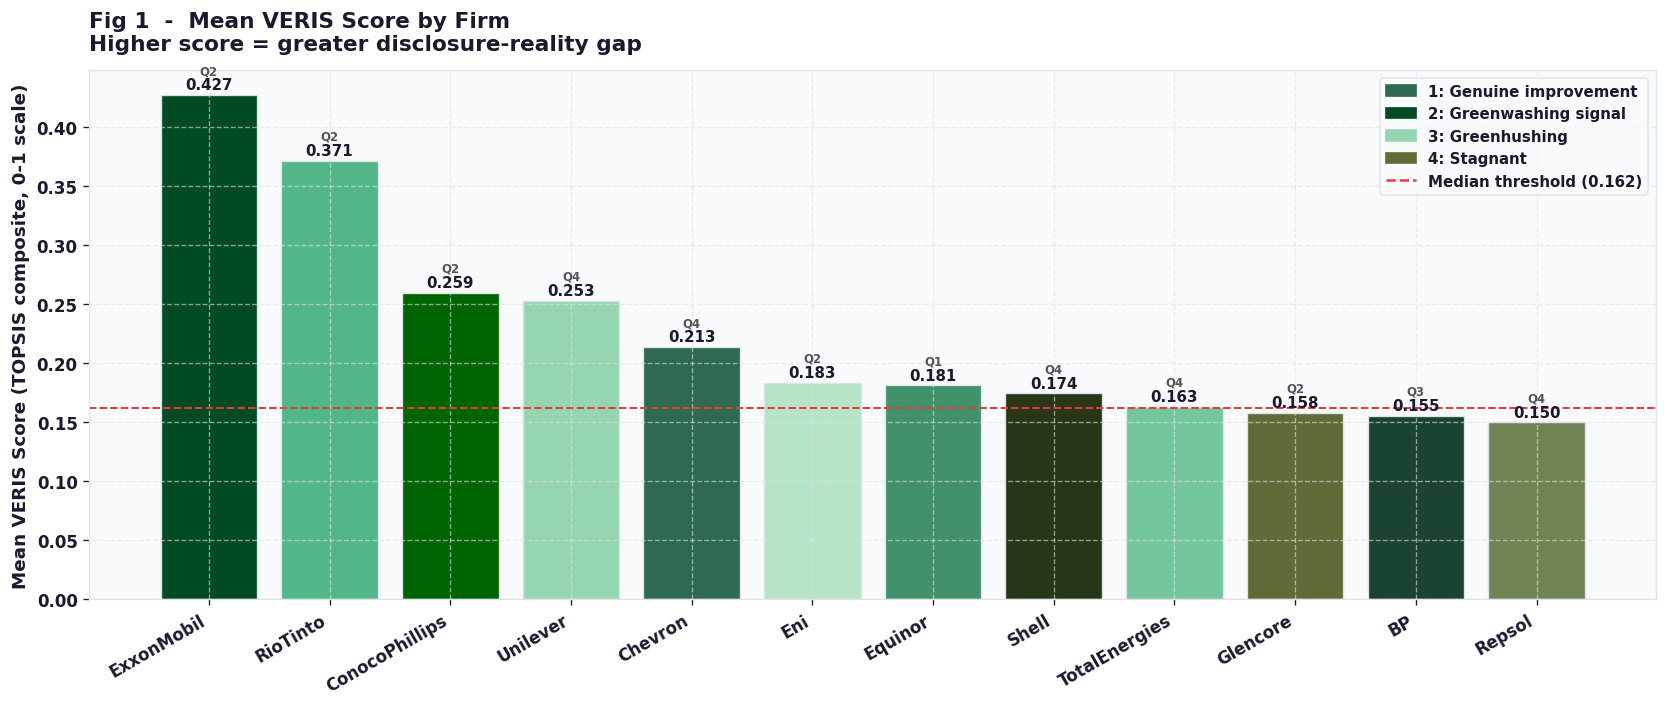

In [3]:
# Figure 01: Mean VERIS by firm (bar).
# Green-gradient bar colours keyed by FIRM, not quadrant.
# Quadrant shown as a small symbol above the value label.

def _best_quadrant(x):
    """Most common valid quadrant; only fall back if all rows are truly invalid."""
    valid = x[~x.astype(str).str.startswith("Insufficient", na=False)]
    if not valid.empty:
        m = valid.mode()
        return m.iloc[0] if not m.empty else "4 - Stagnant"
    # All rows invalid: use VERIS-based proxy (stagnant, not "Insufficient data")
    return "4 - Stagnant"

fig01_data = panel.groupby("firm_name").agg(
    mean_veris=("veris_score", "mean"),
    most_common_quadrant=("greenwashing_quadrant", _best_quadrant),
).reset_index().sort_values("mean_veris", ascending=False)
save_fig_data(fig01_data, "fig01_data.csv")

# Green tones for quadrant categories (theme-consistent)
_GREEN_QUAD_COLORS = {
    "1 - Genuine improvement":   "#2d6a4f",   # deep emerald
    "2 - Greenwashing signal":   "#004b23",   # very dark forest
    "3 - Greenhushing":          "#95d5b2",   # light mint
    "4 - Stagnant":              "#606c38",   # olive
}
_QUAD_SYMBOLS = {
    "1 - Genuine improvement":  "Q1",
    "2 - Greenwashing signal":  "Q2",
    "3 - Greenhushing":         "Q3",
    "4 - Stagnant":             "Q4",
}

fig, ax = plt.subplots(figsize=(14, 6))

# Colour each bar by firm's unique green shade
bar_colors = [GREEN_FIRM_COLORS.get(f, MUTED) for f in fig01_data["firm_name"]]
bars = ax.bar(fig01_data["firm_name"], fig01_data["mean_veris"],
              color=bar_colors, edgecolor=BORDER, linewidth=0.8)

ax.axhline(median_veris, color=WARN, linestyle="--", linewidth=1.2,
           label=f"Median threshold ({median_veris:.3f})")

# Value label + quadrant badge
for b, v, q in zip(bars, fig01_data["mean_veris"], fig01_data["most_common_quadrant"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.005,
            f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
    badge = _QUAD_SYMBOLS.get(q, "")
    if badge:
        ax.text(b.get_x() + b.get_width() / 2, v + 0.018,
                badge, ha="center", fontsize=7, color="#555555")

# Legend: quadrant reference swatcheses (green tones) + median line
import matplotlib.patches as _mp
_quad_handles = [
    _mp.Patch(color=_GREEN_QUAD_COLORS[q], label=q.replace(" - ", ": "))
    for q in ["1 - Genuine improvement", "2 - Greenwashing signal",
              "3 - Greenhushing", "4 - Stagnant"]
]
_median_handle = plt.Line2D([0], [0], color=WARN, linestyle="--", linewidth=1.5,
                             label=f"Median threshold ({median_veris:.3f})")
ax.legend(handles=_quad_handles + [_median_handle], loc="upper right", fontsize=9)

ax.set_ylabel("Mean VERIS Score (TOPSIS composite, 0-1 scale)")
ax.set_title("Fig 1  -  Mean VERIS Score by Firm\nHigher score = greater disclosure-reality gap",
             loc="left", fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_fig(fig, "fig01_veris_bar.png")


19:31:07 [INFO] VERIS -- Saved figure data: fig02_data.csv
19:31:08 [INFO] VERIS -- Saved figure: fig02_emissions_trajectory.png


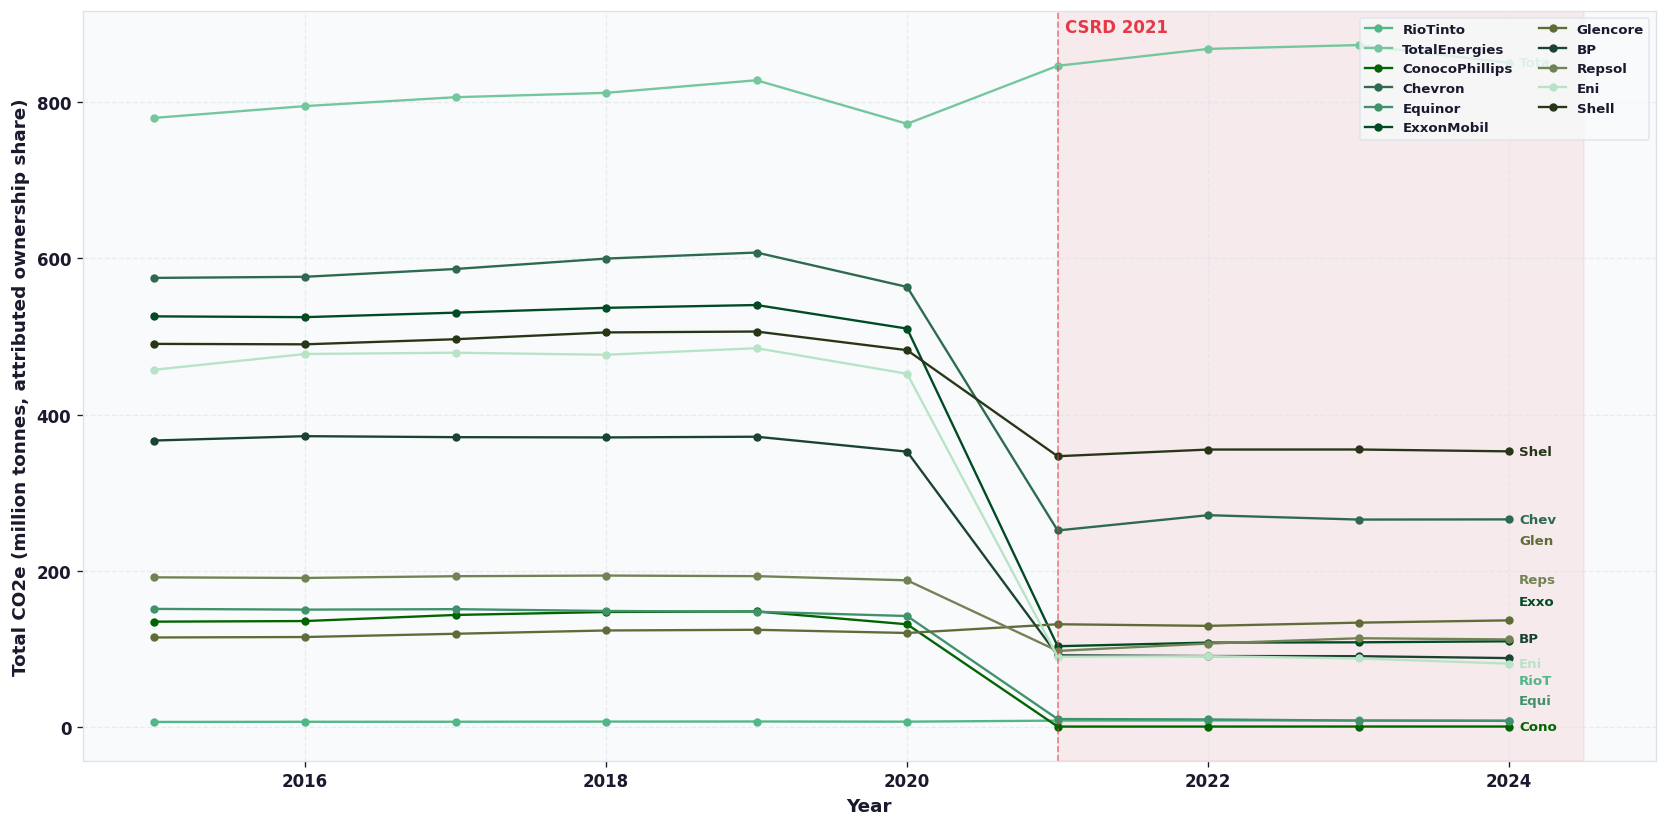

In [4]:
# Figure 02: Emissions trajectory 2015-2024.
fig02_data = veris_em[["firm_name", "year", "co2e_mt", "data_method"]].copy()
save_fig_data(fig02_data, "fig02_data.csv")

fig, ax = plt.subplots(figsize=(14, 7))

# Plot lines
for firm in cfg.ALL_FIRMS:
    sub = fig02_data[fig02_data["firm_name"] == firm].sort_values("year")
    if sub.empty:
        continue
    ax.plot(sub["year"], sub["co2e_mt"], marker="o", linewidth=1.4, markersize=4,
            color=GREEN_FIRM_COLORS.get(firm, MUTED), label=firm)

ax.axvspan(2021, 2024.5, alpha=0.08, color=WARN)
ax.axvline(2021, color=WARN, linestyle="--", linewidth=1, alpha=0.6)
ax.text(2021.05, ax.get_ylim()[1] * 0.97, "CSRD 2021", color=WARN, fontsize=10, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Total CO2e (million tonnes, attributed ownership share)")
ax.legend(loc="upper right", ncol=2, fontsize=8)

# End-of-line labels with collision avoidance (sort by last co2e, stagger overlapping)
_last_pts = []
for firm in cfg.ALL_FIRMS:
    sub = fig02_data[fig02_data["firm_name"] == firm].sort_values("year")
    if not sub.empty:
        _last_pts.append((firm, float(sub.iloc[-1]["year"]), float(sub.iloc[-1]["co2e_mt"])))
_last_pts.sort(key=lambda x: x[2])  # sort by co2e ascending

_y_offsets = [0.0] * len(_last_pts)
for _i in range(1, len(_last_pts)):
    _gap_data = _last_pts[_i][2] - _last_pts[_i-1][2]
    # Estimate: figure is 7in, y-range ~900, so ~900/504pts ≈ 1.8 data-units/pt
    # Two 8pt labels need ~10pt separation → ~18 data-units threshold
    if _gap_data < 25:
        _y_offsets[_i] = _y_offsets[_i-1] + 12  # stack upward in points
    else:
        _y_offsets[_i] = 0.0

for (_firm, _lx, _ly), _yoff in zip(_last_pts, _y_offsets):
    ax.annotate(_firm[:4], (_lx, _ly),
                xytext=(6, _yoff), textcoords="offset points", fontsize=8,
                color=GREEN_FIRM_COLORS.get(_firm, MUTED), va="center")

plt.tight_layout()
save_fig(fig, "fig02_emissions_trajectory.png")


19:31:08 [INFO] VERIS -- Saved figure data: fig03_data.csv
19:31:09 [INFO] VERIS -- Saved figure: fig03_veris_over_time.png


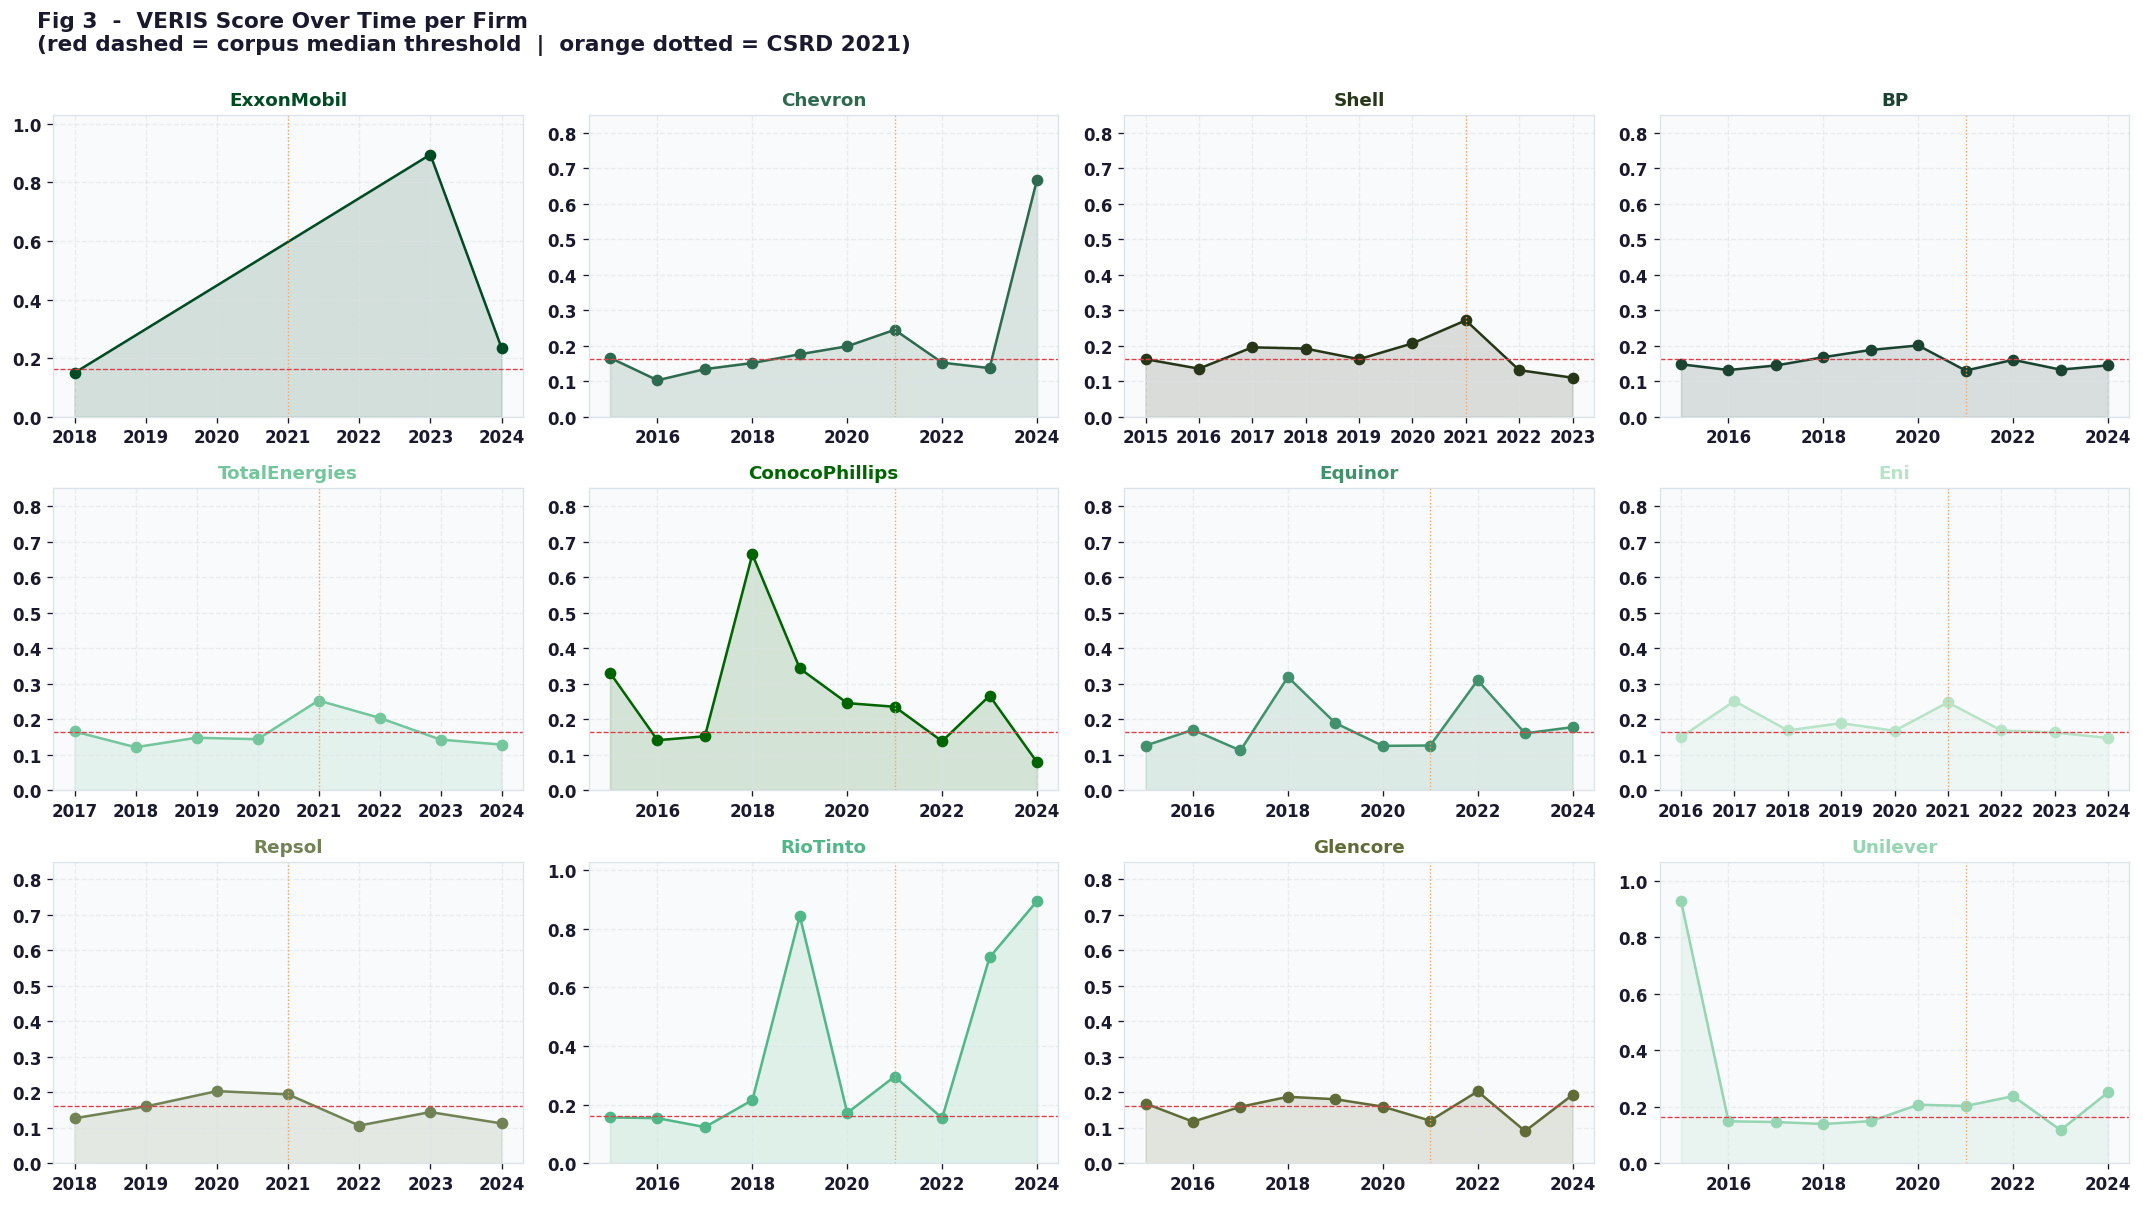

In [5]:
# Figure 03: VERIS per firm over time.
fig03_data = veris_master[["firm_name", "year_from", "year_to", "veris_score", "greenwashing_quadrant"]].copy()
save_fig_data(fig03_data, "fig03_data.csv")

fig, axes = plt.subplots(3, 4, figsize=(18, 10))  # sharey removed so ExxonMobil fits
for ax, firm in zip(axes.ravel(), INDUSTRY_FIRM_ORDER):
    sub = fig03_data[fig03_data["firm_name"] == firm].sort_values("year_to")
    color = GREEN_FIRM_COLORS.get(firm, MUTED)
    ax.fill_between(sub["year_to"], 0, sub["veris_score"], color=color, alpha=0.15)
    ax.plot(sub["year_to"], sub["veris_score"], marker="o", color=color, linewidth=1.5)
    ax.axhline(median_veris, color=WARN, linestyle="--", linewidth=0.8)
    ax.axvline(cfg.CSRD_YEAR, color=AMBER, linestyle=":", linewidth=0.8)
    ax.set_title(firm, fontweight="bold", color=color, fontsize=11)
    _ymax = max(0.85, sub["veris_score"].max() * 1.15 if not sub.empty else 0.85)
    ax.set_ylim(0, _ymax)
fig.suptitle("Fig 3  -  VERIS Score Over Time per Firm\n(red dashed = corpus median threshold  |  orange dotted = CSRD 2021)", fontsize=13, fontweight="bold", x=0.02, ha="left", y=1.00)
plt.tight_layout()
save_fig(fig, "fig03_veris_over_time.png")


19:31:09 [INFO] VERIS -- Saved figure data: fig04_data.csv
19:31:10 [INFO] VERIS -- Saved figure: fig04_greenwashing_matrix.png


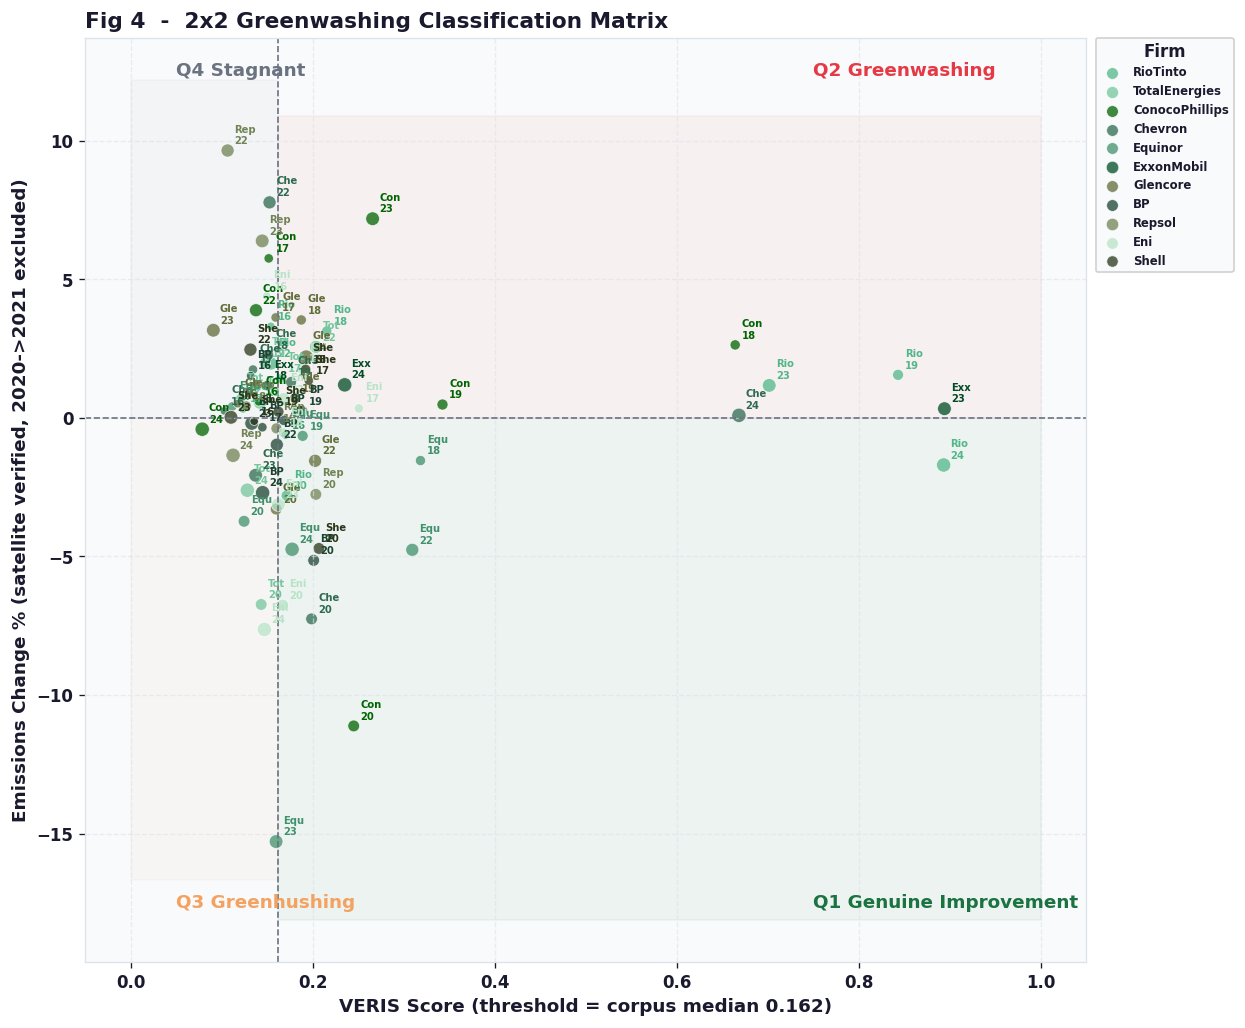

In [6]:
# Figure 04: 2x2 greenwashing classification matrix.
fig04_data = veris_master[["firm_name", "year_from", "year_to", "veris_score", "emissions_delta_pct", "greenwashing_quadrant"]].copy()
fig04_data = fig04_data.dropna(subset=["emissions_delta_pct"])
fig04_data = fig04_data[~fig04_data["greenwashing_quadrant"].str.contains("Insufficient", na=False)]
save_fig_data(fig04_data, "fig04_data.csv")

fig, ax = plt.subplots(figsize=(12, 10))
for firm in cfg.ALL_FIRMS:
    sub = fig04_data[fig04_data["firm_name"] == firm]
    if sub.empty:
        continue
    sizes = 20 + (sub["year_to"] - 2015) * 6
    ax.scatter(sub["veris_score"], sub["emissions_delta_pct"] * 100,
               s=sizes, color=GREEN_FIRM_COLORS.get(firm, MUTED),
               alpha=0.75, edgecolor="white", linewidth=0.5, label=firm)
    for _, r in sub.iterrows():
        ax.annotate(f"{firm[:3]}\n{int(r['year_to'])-2000}",
                    (r["veris_score"], r["emissions_delta_pct"] * 100),
                    xytext=(4, 4), textcoords="offset points", fontsize=6,
                    color=GREEN_FIRM_COLORS.get(firm, MUTED))
ax.axvline(median_veris, color=MUTED, linestyle="--", linewidth=1)
ax.axhline(0, color=MUTED, linestyle="--", linewidth=1)
ax.fill_between([median_veris, 1], 0, ax.get_ylim()[1] if not fig04_data.empty else 10, alpha=0.05, color=WARN, zorder=0)
ax.fill_between([0, median_veris], 0, ax.get_ylim()[1] if not fig04_data.empty else 10, alpha=0.04, color=MUTED, zorder=0)
ax.fill_between([0, median_veris], ax.get_ylim()[0] if not fig04_data.empty else -10, 0, alpha=0.05, color=AMBER, zorder=0)
ax.fill_between([median_veris, 1], ax.get_ylim()[0] if not fig04_data.empty else -10, 0, alpha=0.05, color=PRIMARY, zorder=0)
ax.text(0.05, ax.get_ylim()[1] * 0.9, "Q4 Stagnant", fontsize=11, color=MUTED, fontweight="bold")
ax.text(0.05, ax.get_ylim()[0] * 0.9, "Q3 Greenhushing", fontsize=11, color=AMBER, fontweight="bold")
ax.text(0.75 if fig04_data["veris_score"].max() > 0.75 else 0.55, ax.get_ylim()[1] * 0.9, "Q2 Greenwashing", fontsize=11, color=WARN, fontweight="bold")
ax.text(0.75 if fig04_data["veris_score"].max() > 0.75 else 0.55, ax.get_ylim()[0] * 0.9, "Q1 Genuine Improvement", fontsize=11, color=PRIMARY, fontweight="bold")
ax.set_xlabel(f"VERIS Score (threshold = corpus median {median_veris:.3f})")
ax.set_ylabel("Emissions Change % (satellite verified, 2020->2021 excluded)")
ax.set_title("Fig 4  -  2x2 Greenwashing Classification Matrix", loc="left", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0,
          fontsize=7, ncol=1, title="Firm", framealpha=0.9,
          edgecolor="#cccccc")
plt.subplots_adjust(right=0.82)  # make room for legend outside
save_fig(fig, "fig04_greenwashing_matrix.png")


19:31:10 [INFO] VERIS -- Saved figure data: fig05_data.csv
19:31:11 [INFO] VERIS -- Saved figure: fig05_sbert_heatmap.png


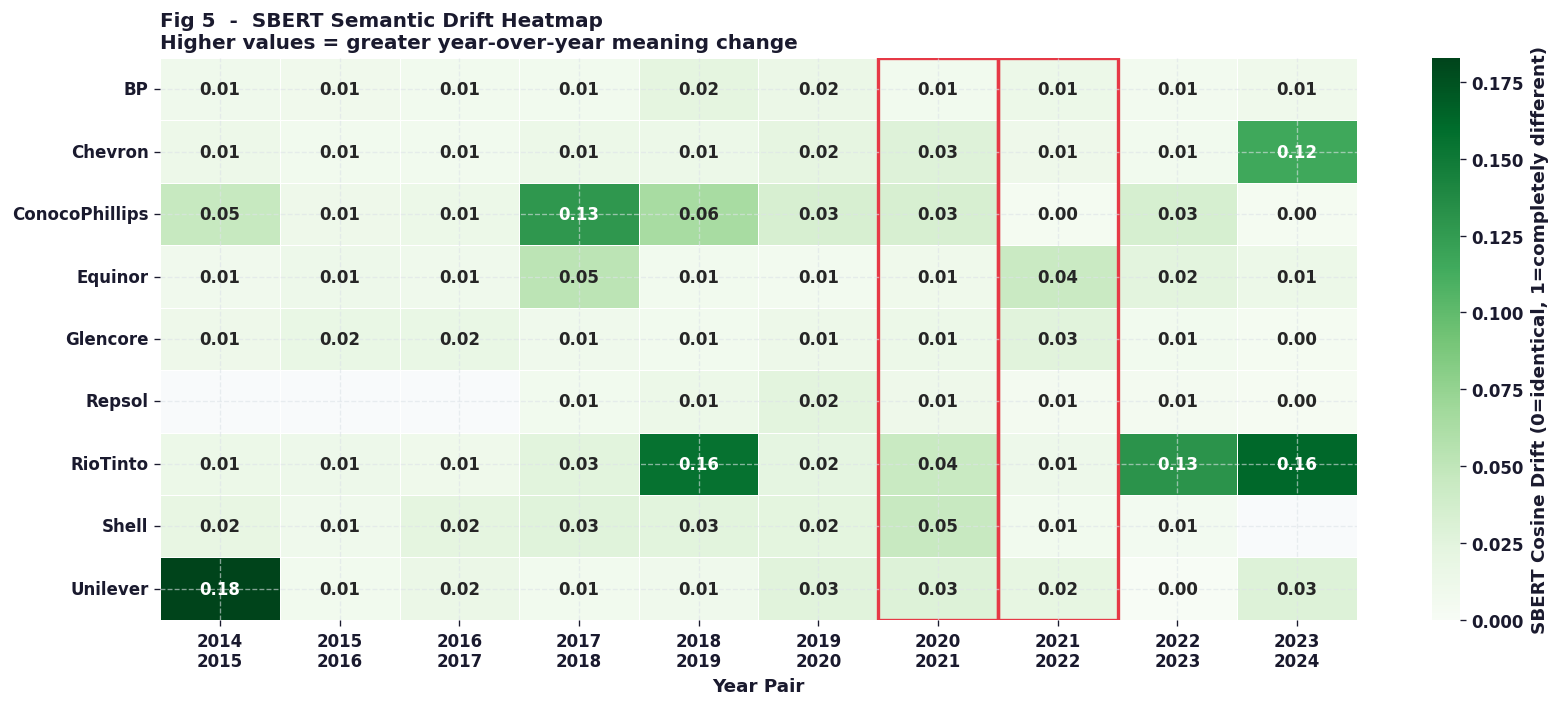

In [7]:
# Figure 05: SBERT semantic drift heatmap.
# Remove firms with insufficient SBERT drift data for this chart
_FIG05_EXCLUDE = {"ExxonMobil", "Eni", "TotalEnergies"}
fig05_data = drift.pivot_table(index="firm_name", columns="year_from", values="sbert_drift", aggfunc="first")
fig05_data = fig05_data.loc[~fig05_data.index.isin(_FIG05_EXCLUDE)]
fig05_data.reset_index().to_csv(cfg.CSV_DIR / "fig05_data.csv", index=False)
log.info("Saved figure data: fig05_data.csv")

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(fig05_data, annot=True, fmt=".2f", cmap="Greens",
            cbar_kws={"label": "SBERT Cosine Drift (0=identical, 1=completely different)"},
            linewidths=0.5, linecolor="white", ax=ax)
for i, y in enumerate(fig05_data.columns):
    if y in [2020, 2021]:
        ax.add_patch(plt.Rectangle((i, 0), 1, len(fig05_data), fill=False, edgecolor=WARN, linewidth=2))
ax.set_xlabel("Year Pair")
ax.set_xticklabels([f"{int(y)}\n{int(y)+1}" for y in fig05_data.columns], rotation=0)
ax.set_ylabel("")
ax.set_title("Fig 5  -  SBERT Semantic Drift Heatmap\nHigher values = greater year-over-year meaning change", loc="left", fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig05_sbert_heatmap.png")


19:31:11 [INFO] VERIS -- Saved figure data: fig06_data.csv
19:31:11 [INFO] VERIS -- Saved figure: fig06_nlp_decomposition.png


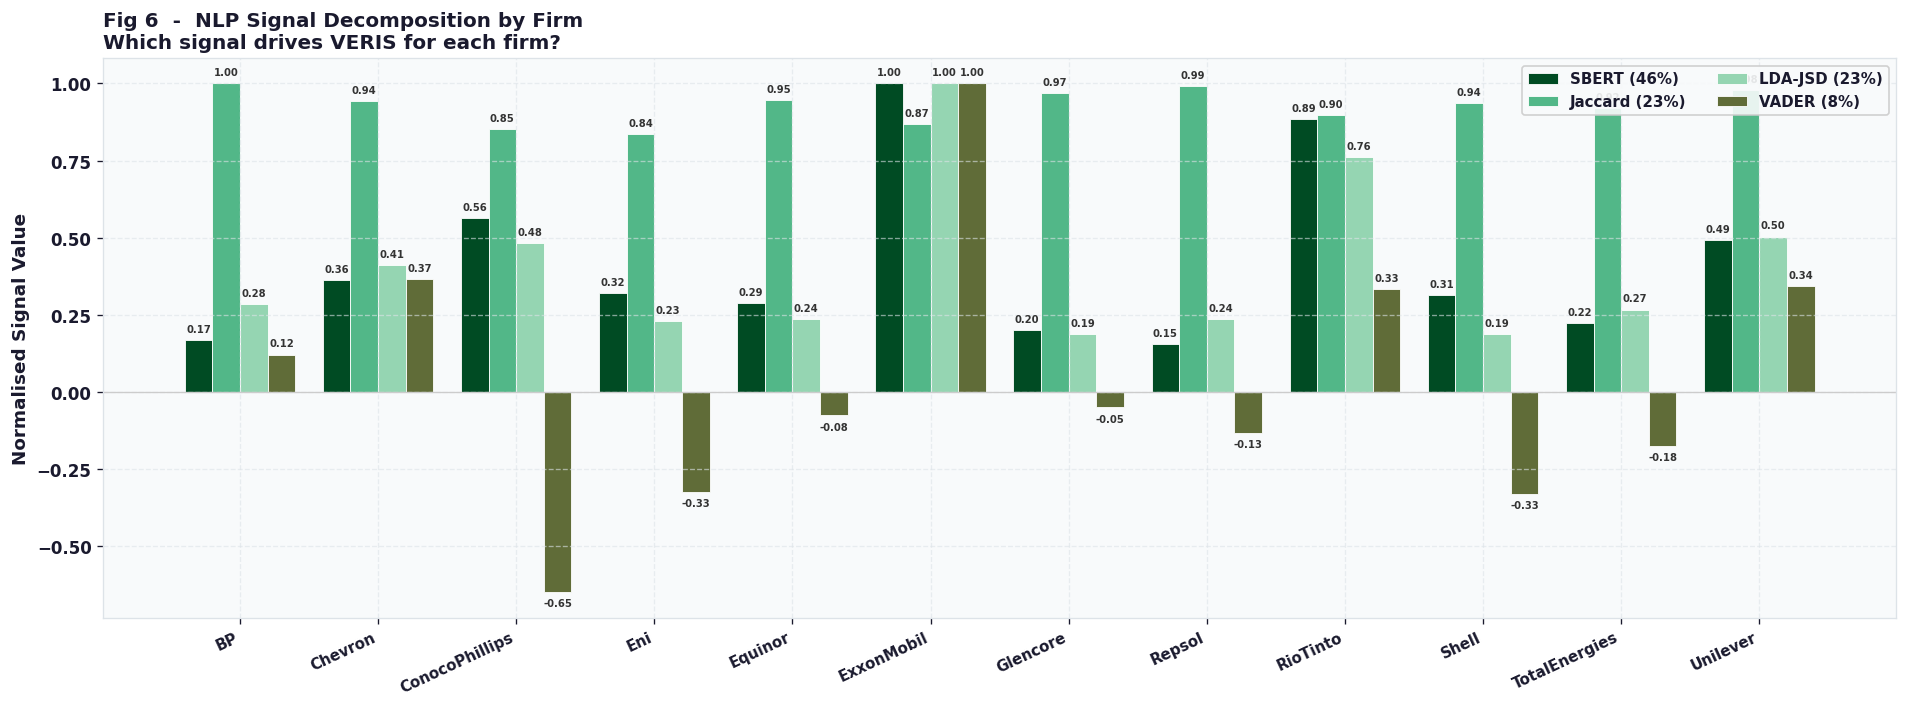

In [8]:
# Figure 06: NLP signal decomposition by firm (normalised to max).
sig_cols = ["sbert_drift", "jaccard_overlap", "lda_jsd", "vader_delta"]
fig06_rows = []
for firm, group in panel.groupby("firm_name"):
    for c in sig_cols:
        fig06_rows.append({"firm_name": firm, "signal": c, "mean_value": float(group[c].mean())})
fig06_raw = pd.DataFrame(fig06_rows)
for s in sig_cols:
    mask = fig06_raw["signal"] == s
    vmax = fig06_raw.loc[mask, "mean_value"].abs().max() or 1.0
    fig06_raw.loc[mask, "normalised"] = fig06_raw.loc[mask, "mean_value"] / vmax
fig06_data = fig06_raw.pivot(index="firm_name", columns="signal", values="normalised").reset_index()
save_fig_data(fig06_data, "fig06_data.csv")

# Green-gradient signal colours (all green, distinguishable)
_SIG_COLORS = {
    "sbert_drift":     "#004b23",  # very dark forest
    "jaccard_overlap": "#52b788",  # medium sage
    "lda_jsd":         "#95d5b2",  # light mint
    "vader_delta":     "#606c38",  # olive green - still distinguishable from other greens
}

w_pct = ahp_weights_df.set_index("criterion")["weight_pct"]
_sig_labels = {
    "sbert_drift":     f"SBERT ({w_pct.get('sbert_drift',46):.0f}%)",
    "jaccard_overlap": f"Jaccard ({w_pct.get('jaccard_overlap',23):.0f}%)",
    "lda_jsd":         f"LDA-JSD ({w_pct.get('lda_jsd',23):.0f}%)",
    "vader_delta":     f"VADER ({w_pct.get('vader_delta',8):.0f}%)",
}

firms = fig06_data["firm_name"].tolist()
x = np.arange(len(firms))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 6))

for i, s in enumerate(sig_cols):
    vals = fig06_data[s].values
    bars = ax.bar(x + (i - 1.5) * width, vals, width,
                  label=_sig_labels[s], color=_SIG_COLORS[s],
                  edgecolor="white", linewidth=0.5)
    # Add value label on each bar
    for bar, v in zip(bars, vals):
        if abs(v) > 0.05:  # only label bars large enough to read
            va = "bottom" if v >= 0 else "top"
            offset = 2 if v >= 0 else -2
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.02 if v >= 0 else -0.02),
                    f"{v:.2f}", ha="center", va=va, fontsize=6,
                    color="#333333", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(firms, rotation=25, ha="right", fontsize=9)
ax.axhline(0, color="#cccccc", linewidth=0.8)
ax.set_ylabel("Normalised Signal Value")
ax.legend(ncol=2, loc="upper right", fontsize=9,
          framealpha=0.9, edgecolor="#cccccc")
ax.set_title("Fig 6  -  NLP Signal Decomposition by Firm\nWhich signal drives VERIS for each firm?",
             loc="left", fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig06_nlp_decomposition.png")


19:31:11 [INFO] VERIS -- Saved figure data: fig07_data.csv
19:31:12 [INFO] VERIS -- Saved figure: fig07_fog_ttr.png


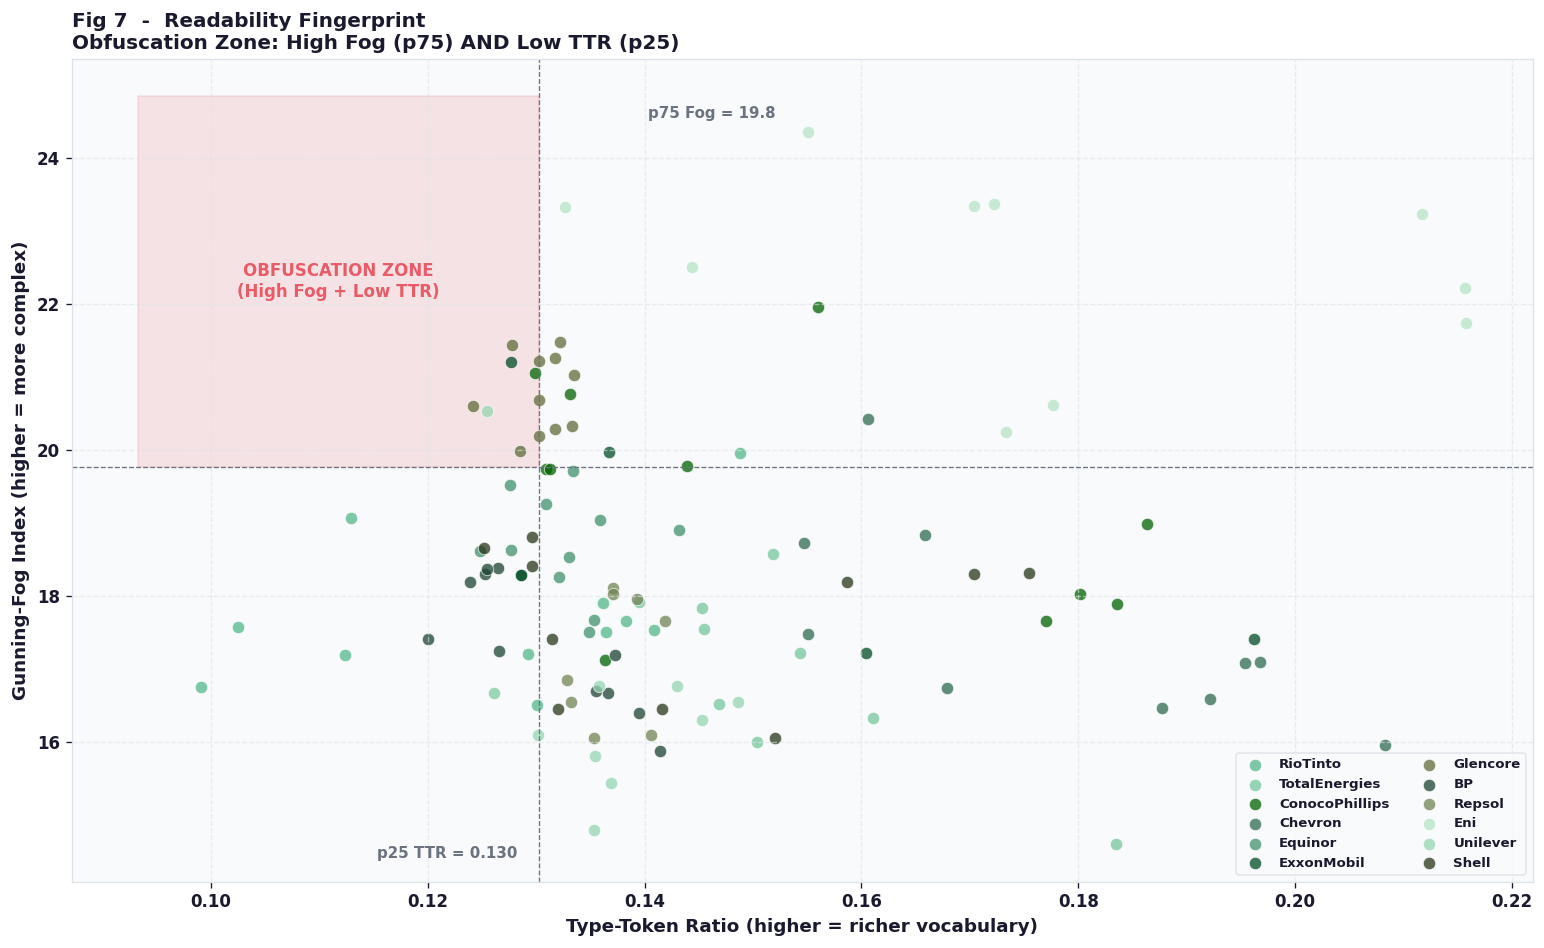

In [9]:
# Figure 07: Readability fingerprint (Fog vs TTR with obfuscation zone).
fig07_data = forensic[["firm_name", "year", "gunning_fog_index", "type_token_ratio", "obfuscation_flag"]].copy()
save_fig_data(fig07_data, "fig07_data.csv")

fog_p75 = forensic["gunning_fog_index"].quantile(0.75)
ttr_p25 = forensic["type_token_ratio"].quantile(0.25)

fig, ax = plt.subplots(figsize=(13, 8))
for firm in cfg.ALL_FIRMS:
    sub = fig07_data[fig07_data["firm_name"] == firm]
    if sub.empty:
        continue
    ax.scatter(sub["type_token_ratio"], sub["gunning_fog_index"],
               s=55, color=GREEN_FIRM_COLORS.get(firm, MUTED), alpha=0.75,
               edgecolor="white", linewidth=0.5, label=firm)
ax.axhline(fog_p75, color=MUTED, linestyle="--", linewidth=0.8)
ax.axvline(ttr_p25, color=MUTED, linestyle="--", linewidth=0.8)
ax.text(ttr_p25 + 0.01, ax.get_ylim()[1] - 0.3, f"p75 Fog = {fog_p75:.1f}", fontsize=9, color=MUTED)
ax.text(ttr_p25 - 0.002, ax.get_ylim()[0] + 0.3, f"p25 TTR = {ttr_p25:.3f}", fontsize=9, color=MUTED, ha="right")
ylim = ax.get_ylim(); xlim = ax.get_xlim()
ax.fill_between([xlim[0], ttr_p25], fog_p75, ylim[1], alpha=0.12, color=WARN, zorder=0)
ax.text(xlim[0] + (ttr_p25 - xlim[0]) / 2, fog_p75 + (ylim[1] - fog_p75) / 2,
        "OBFUSCATION ZONE\n(High Fog + Low TTR)", ha="center", va="center",
        color=WARN, fontsize=10, fontweight="bold", alpha=0.8)
ax.set_xlabel("Type-Token Ratio (higher = richer vocabulary)")
ax.set_ylabel("Gunning-Fog Index (higher = more complex)")
ax.set_title("Fig 7  -  Readability Fingerprint\nObfuscation Zone: High Fog (p75) AND Low TTR (p25)", loc="left", fontsize=12, fontweight="bold")
ax.legend(ncol=2, loc="lower right", fontsize=8)
plt.tight_layout()
save_fig(fig, "fig07_fog_ttr.png")


19:31:12 [INFO] VERIS -- Saved figure data: fig08_data.csv
19:31:12 [INFO] VERIS -- Saved figure: fig08_controversy_timeline.png


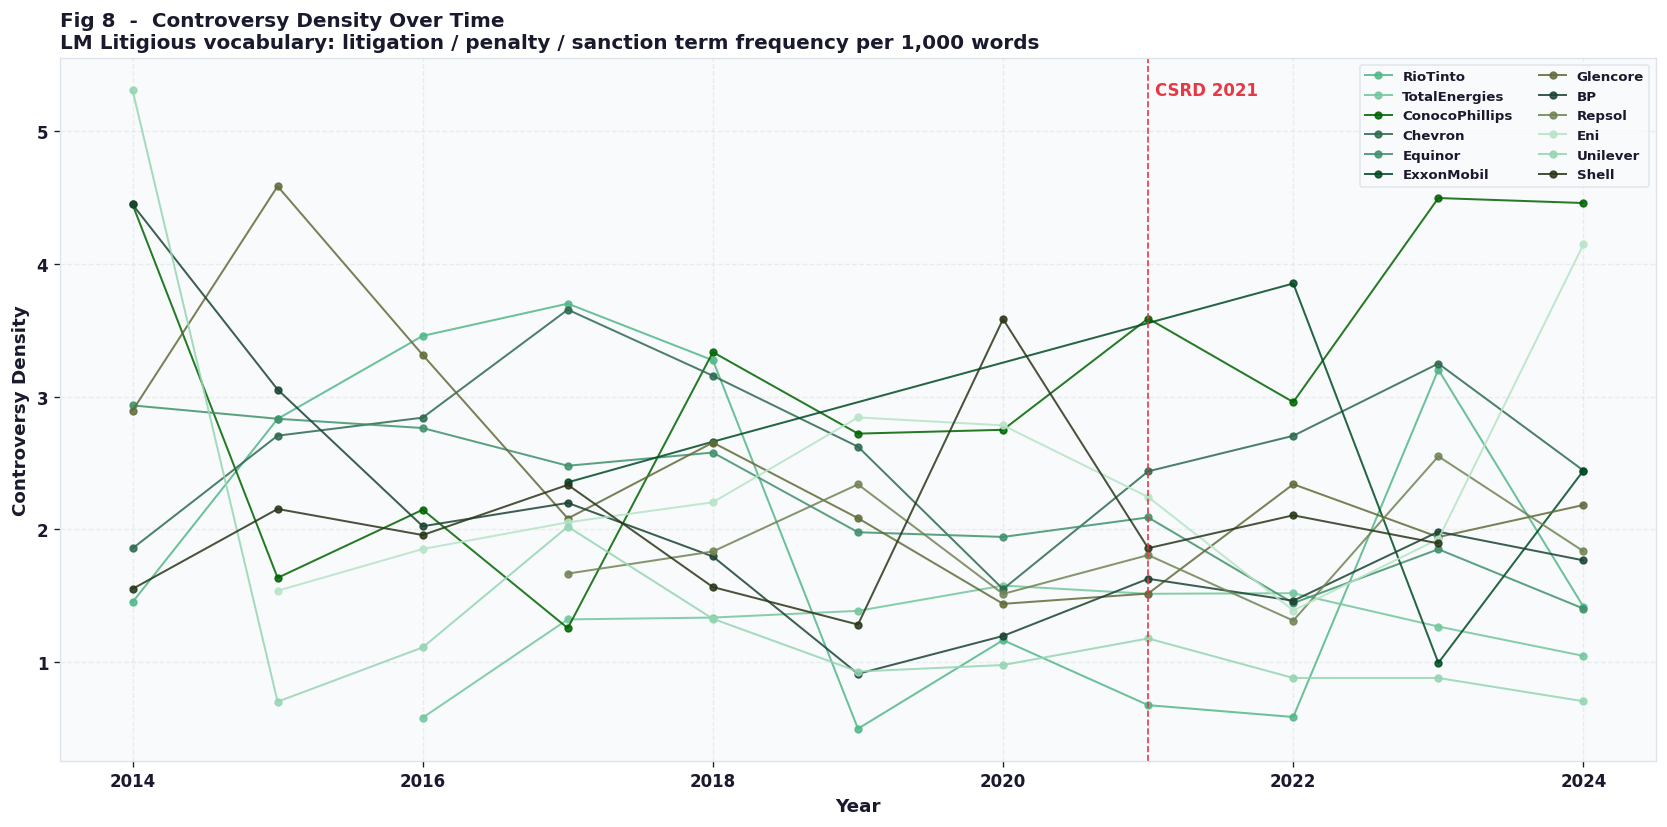

In [10]:
# Figure 08: Controversy density timeline.
fig08_data = forensic[["firm_name", "year", "controversy_density"]].copy()
save_fig_data(fig08_data, "fig08_data.csv")

fig, ax = plt.subplots(figsize=(14, 7))
for firm in cfg.ALL_FIRMS:
    sub = fig08_data[fig08_data["firm_name"] == firm].sort_values("year")
    if sub.empty:
        continue
    ax.plot(sub["year"], sub["controversy_density"], marker="o", linewidth=1.2, markersize=4,
            color=GREEN_FIRM_COLORS.get(firm, MUTED), label=firm, alpha=0.85)
ax.axvline(cfg.CSRD_YEAR, color=WARN, linestyle="--", linewidth=1)
ax.text(cfg.CSRD_YEAR + 0.05, ax.get_ylim()[1] * 0.95, "CSRD 2021", color=WARN, fontsize=10, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Controversy Density")
ax.set_title("Fig 8  -  Controversy Density Over Time\nLM Litigious vocabulary: litigation / penalty / sanction term frequency per 1,000 words", loc="left", fontsize=12, fontweight="bold")
ax.legend(ncol=2, loc="upper right", fontsize=8)
plt.tight_layout()
save_fig(fig, "fig08_controversy_timeline.png")


19:31:12 [INFO] VERIS -- Saved figure data: fig09_data.csv
19:31:13 [INFO] VERIS -- Saved figure: fig09_social_vs_veris.png


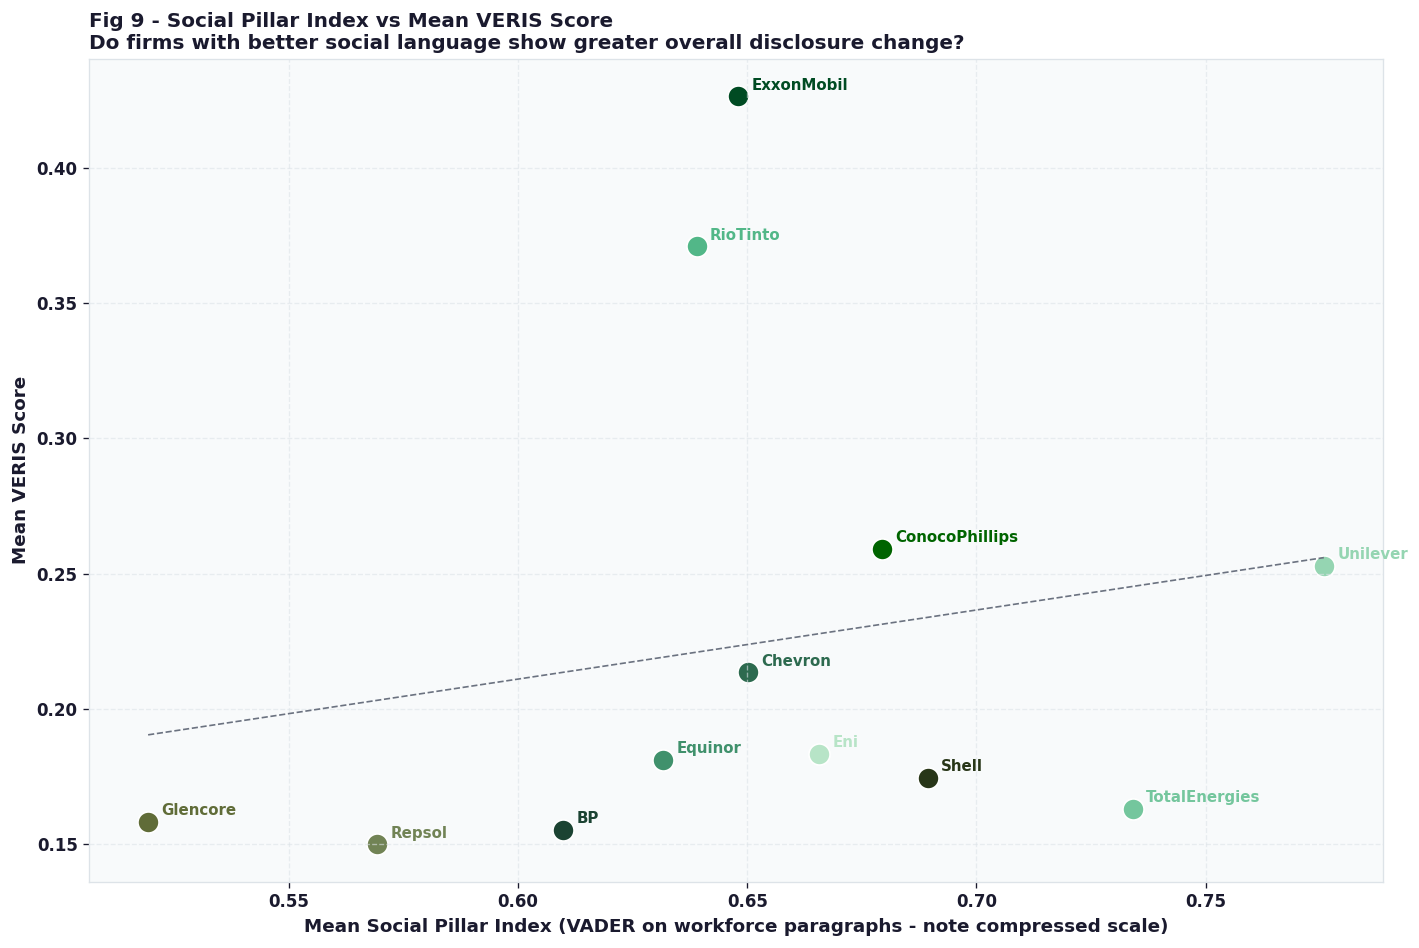

In [11]:
# Figure 09: Social pillar index vs mean VERIS (firm level).
f09_veris = panel.groupby("firm_name")["veris_score"].mean()
f09_social = forensic.groupby("firm_name")["social_index"].mean()
fig09_data = pd.concat([f09_veris, f09_social], axis=1).reset_index().rename(
    columns={"veris_score": "mean_veris", "social_index": "mean_social_index"})
save_fig_data(fig09_data, "fig09_data.csv")

fig, ax = plt.subplots(figsize=(12, 8))
for _, r in fig09_data.iterrows():
    ax.scatter(r["mean_social_index"], r["mean_veris"], s=160,
               color=GREEN_FIRM_COLORS.get(r["firm_name"], MUTED), edgecolor="white")
    ax.annotate(r["firm_name"], (r["mean_social_index"], r["mean_veris"]),
                xytext=(8, 4), textcoords="offset points", fontsize=9,
                color=GREEN_FIRM_COLORS.get(r["firm_name"], MUTED))
if len(fig09_data) >= 2:
    slope, intercept = np.polyfit(fig09_data["mean_social_index"], fig09_data["mean_veris"], 1)
    xs = np.linspace(fig09_data["mean_social_index"].min(), fig09_data["mean_social_index"].max(), 10)
    ax.plot(xs, slope * xs + intercept, color=MUTED, linestyle="--", linewidth=1)
ax.set_xlabel("Mean Social Pillar Index (VADER on workforce paragraphs - note compressed scale)")
ax.set_ylabel("Mean VERIS Score")
ax.set_title("Fig 9 - Social Pillar Index vs Mean VERIS Score\nDo firms with better social language show greater overall disclosure change?", loc="left", fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig09_social_vs_veris.png")


19:31:13 [INFO] VERIS -- Saved figure data: fig10_data.csv
19:31:13 [INFO] VERIS -- Saved figure: fig10_sensitivity.png


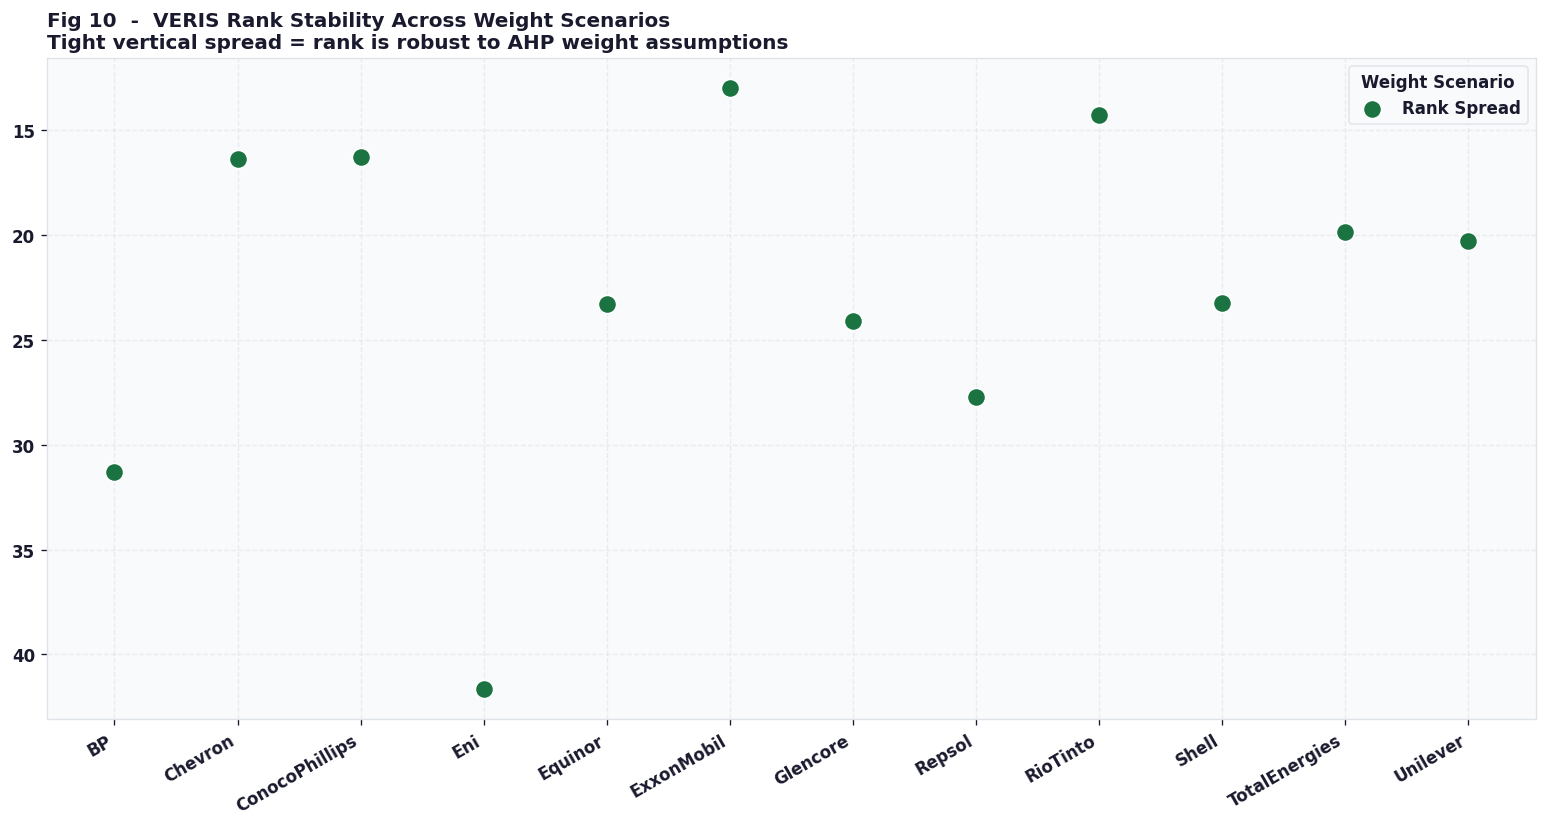

In [12]:
# Figure 10: VERIS rank stability across weight scenarios.
fig10_data = sens.groupby("Firm")["Rank Spread"].mean().reset_index().rename(columns={"Rank Spread": "mean_rank_spread"})
save_fig_data(fig10_data, "fig10_data.csv")

fig, ax = plt.subplots(figsize=(13, 7))
firms = fig10_data["Firm"].tolist()
ax.scatter(firms, fig10_data["mean_rank_spread"], s=120, color=PRIMARY, edgecolor="white", label="Rank Spread", zorder=3)
ax.invert_yaxis()
ax.set_title("Fig 10  -  VERIS Rank Stability Across Weight Scenarios\nTight vertical spread = rank is robust to AHP weight assumptions", loc="left", fontsize=12, fontweight="bold")
ax.set_xticklabels(firms, rotation=30, ha="right")
ax.legend(title="Weight Scenario", loc="upper right")
plt.tight_layout()
save_fig(fig, "fig10_sensitivity.png")

19:31:13 [INFO] VERIS -- Saved figure data: fig11_data.csv
19:31:13 [INFO] VERIS -- Saved figure: fig11_pre_post_csrd.png


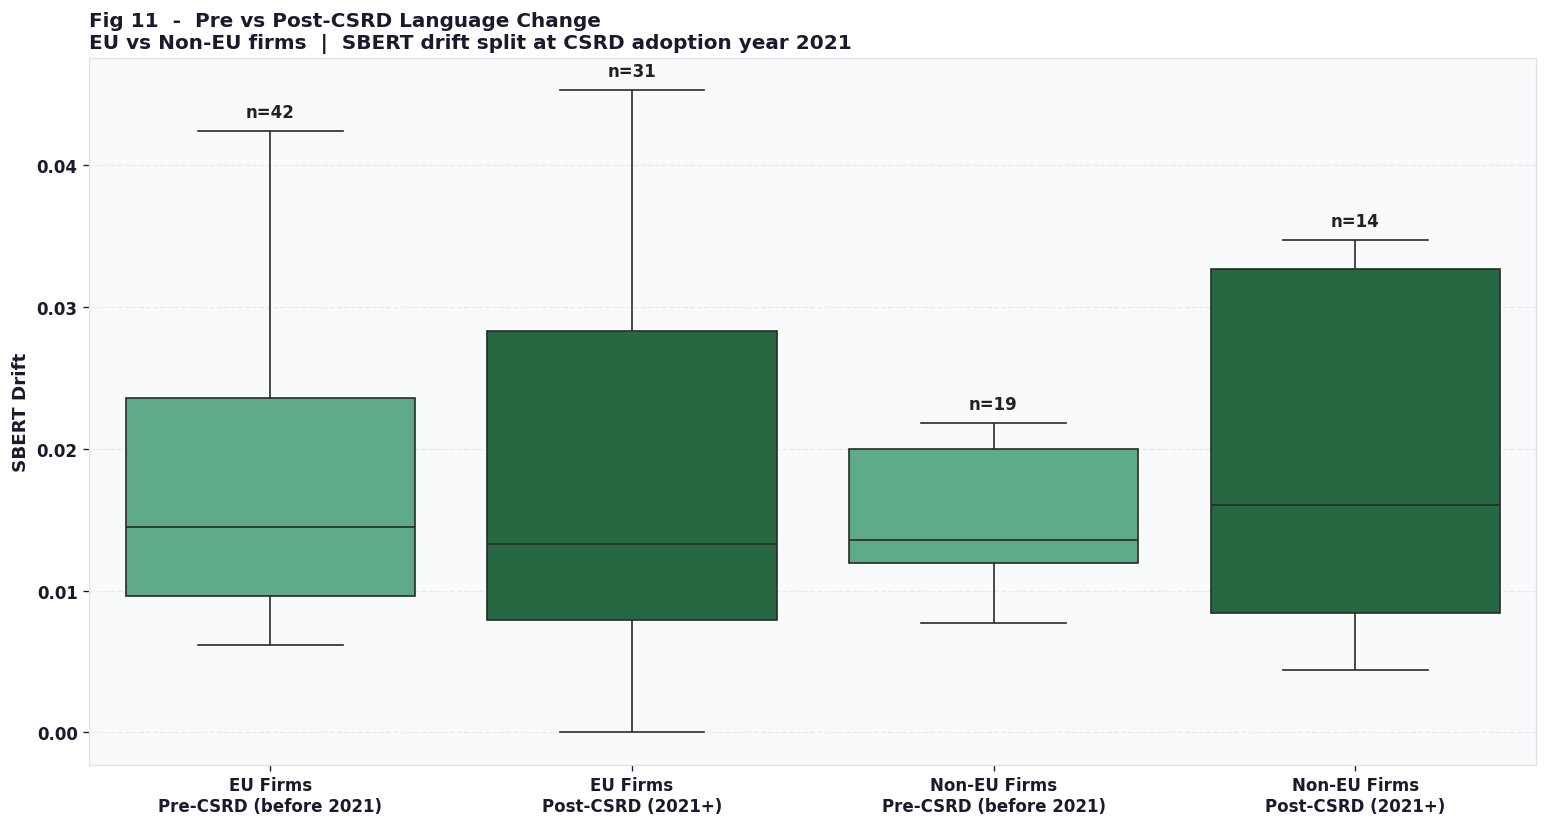

In [13]:
# Figure 11: Pre vs post CSRD language change box plot (EU vs non-EU).
_panel = panel.dropna(subset=['sbert_drift']).copy()
_panel['eu_flag'] = _panel['firm_name'].map({f: v['eu'] for f, v in cfg.COMPANIES.items()})
_panel['period'] = _panel['year_to'].apply(lambda y: 'Post-CSRD (2021+)' if y >= cfg.CSRD_YEAR else 'Pre-CSRD (before 2021)')

def _make_group(r):
    prefix = 'EU' if r['eu_flag'] else 'Non-EU'
    return prefix + ' Firms\n' + r['period']

_panel['group'] = _panel.apply(_make_group, axis=1)

fig11_data = _panel[['firm_name', 'year_from', 'year_to', 'sbert_drift', 'eu_flag', 'period', 'group']].copy()
save_fig_data(fig11_data, 'fig11_data.csv')

order = ['EU Firms\nPre-CSRD (before 2021)', 'EU Firms\nPost-CSRD (2021+)',
         'Non-EU Firms\nPre-CSRD (before 2021)', 'Non-EU Firms\nPost-CSRD (2021+)']
fig, ax = plt.subplots(figsize=(13, 7))
sns.boxplot(data=fig11_data, x='group', y='sbert_drift', order=order,
            palette=[LIGHT, PRIMARY, LIGHT, PRIMARY], ax=ax,
            showfliers=False)

fig.canvas.draw()

for i, g in enumerate(order):
    vals = fig11_data.loc[fig11_data['group'] == g, 'sbert_drift'].dropna()
    n = len(vals)
    if n == 0:
        continue
    _cap_y = None
    for line in ax.lines:
        xdata = line.get_xdata()
        ydata = line.get_ydata()
        if (len(xdata) == 2 and len(ydata) == 2
                and abs(ydata[0] - ydata[1]) < 1e-10
                and abs(xdata[0] - xdata[1]) < 0.6
                and abs(np.mean(xdata) - i) < 0.3):
            if _cap_y is None or ydata[0] > _cap_y:
                _cap_y = float(ydata[0])
    if _cap_y is None:
        q75 = float(np.percentile(vals, 75))
        iqr = float(q75 - np.percentile(vals, 25))
        _cap_y = float(min(q75 + 1.5 * iqr, vals.max()))
    _yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
    ax.text(i, _cap_y + _yrange * 0.015, 'n=' + str(n),
            ha='center', va='bottom', fontsize=10,
            color='#222222', fontweight='bold')

ax.set_xlabel('')
ax.set_ylabel('SBERT Drift')
ax.set_title('Fig 11  -  Pre vs Post-CSRD Language Change\nEU vs Non-EU firms  |  SBERT drift split at CSRD adoption year 2021',
             loc='left', fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'fig11_pre_post_csrd.png')


19:31:14 [INFO] VERIS -- Saved figure data: fig12_data.csv
19:31:14 [INFO] VERIS -- Saved figure: fig12_forest_plot.png


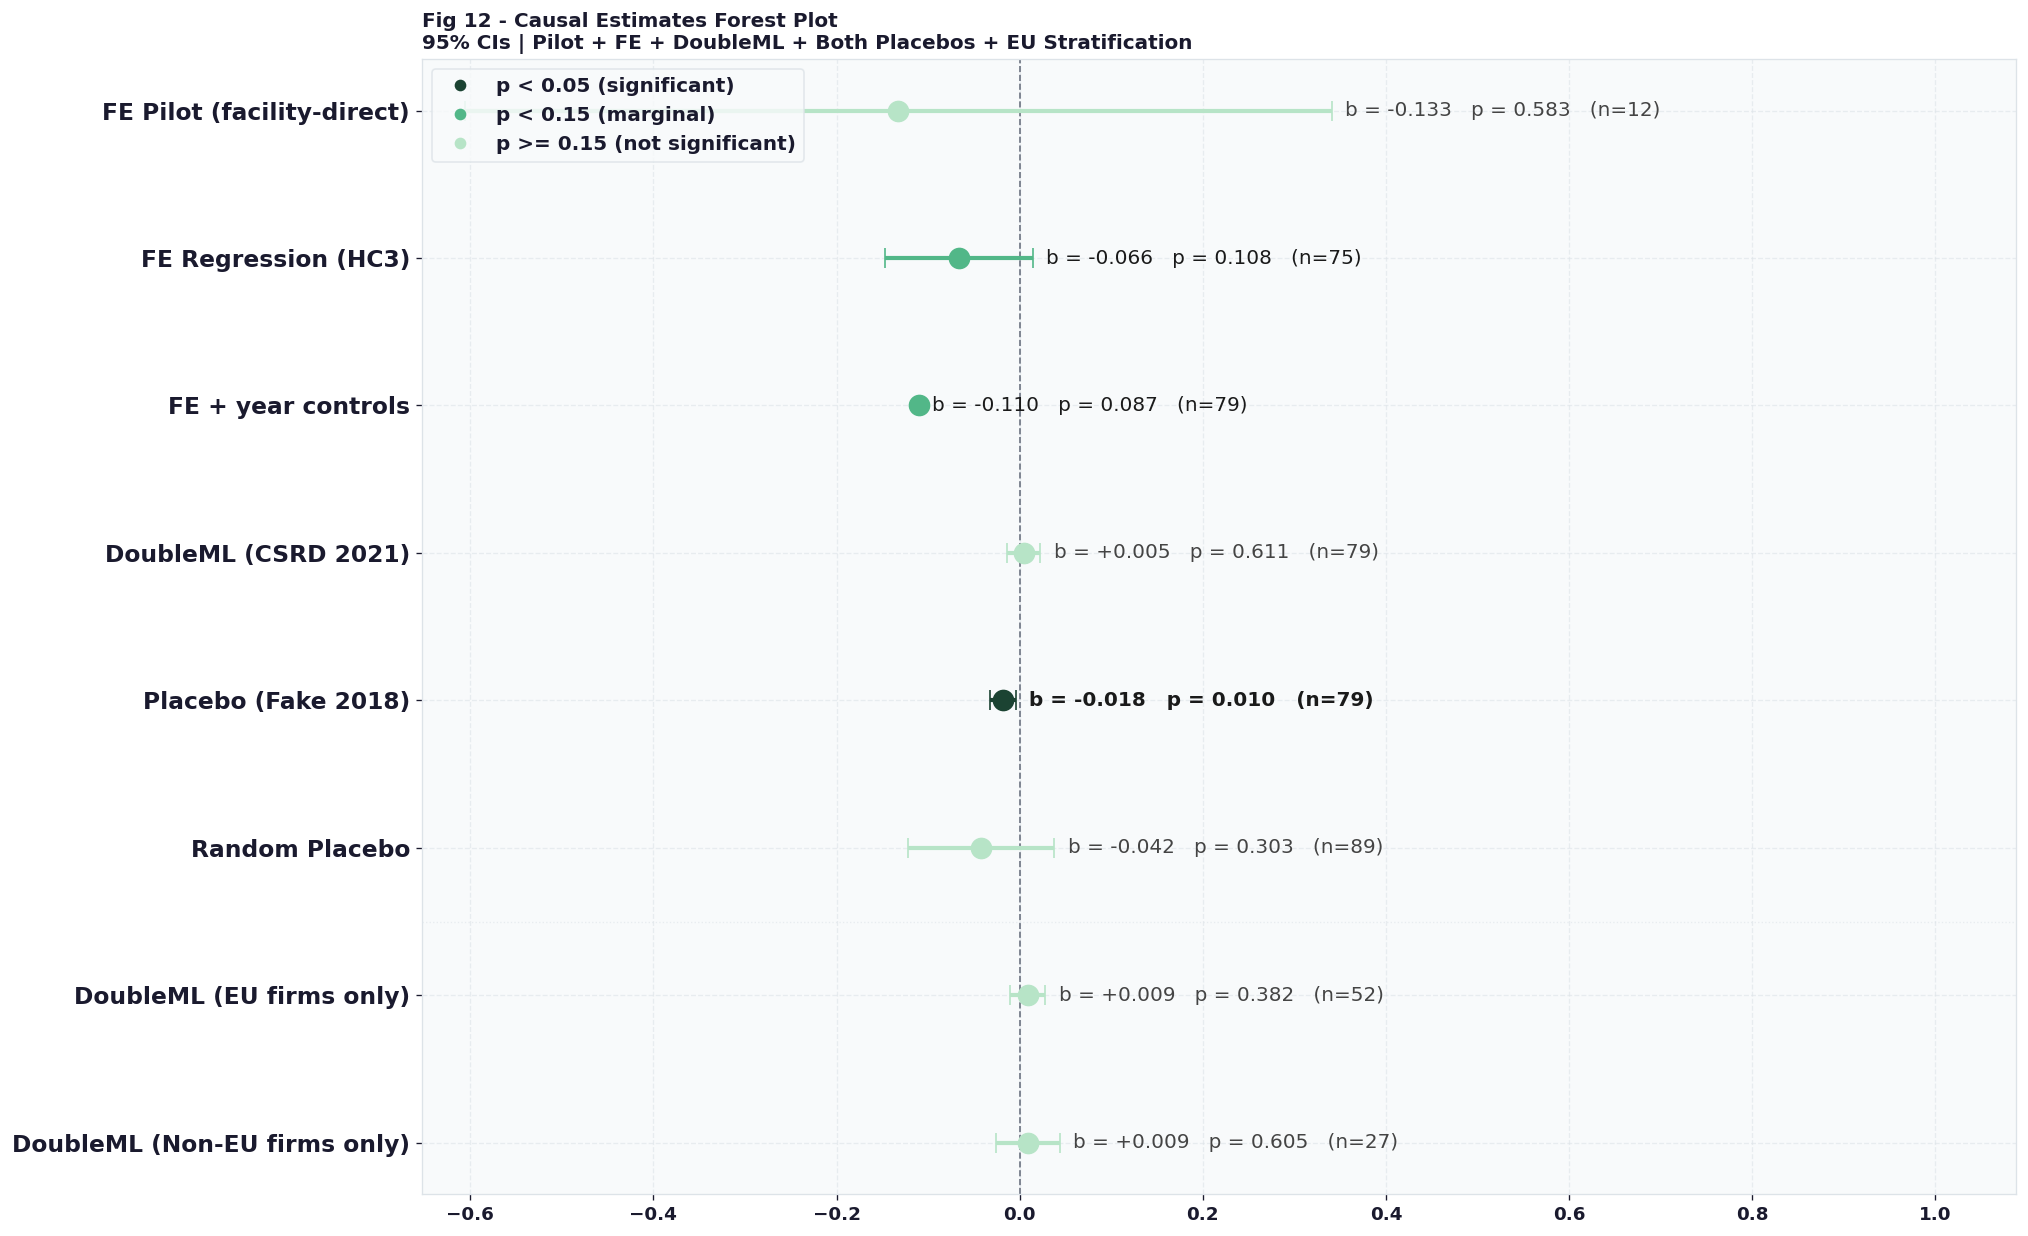

In [14]:
# Figure 12: Causal estimates forest plot.
# After LDA computationed 05_causal_inference.ipynb, causal CSV has 8 rows:
# 6 original + DoubleML (EU firms only) + DoubleML (Non-EU firms only).
fig12_data = causal.copy()

# Drop any rows where theta is NaN (underpowered strata with n<10)
fig12_data = fig12_data.dropna(subset=["theta"]).reset_index(drop=True)
save_fig_data(fig12_data, "fig12_data.csv")

# Green-gradient significance colours
_SIG_COLOR   = "#1b4332"   # dark forest  - p < 0.05
_MARG_COLOR  = "#52b788"   # medium sage  - p < 0.15
_NS_COLOR    = "#b7e4c7"   # light mint   - p >= 0.15

# Dynamic height: 1.0 inch per row, minimum 7
_n_rows = len(fig12_data)
_fig_h  = max(8, _n_rows * 1.3)

fig, ax = plt.subplots(figsize=(17, _fig_h))
y_pos = np.arange(_n_rows)[::-1]
ax.axvline(0, color=MUTED, linestyle="--", linewidth=1)

# Draw a light separator before the EU-stratified rows (last 2 rows of the ordered CSV)
_eu_methods = {"DoubleML (EU firms only)", "DoubleML (Non-EU firms only)"}
_separator_drawn = False

for i, (y, (_, row)) in enumerate(zip(y_pos, fig12_data.iterrows())):
    # Separator line before EU stratified block
    if row["method"] in _eu_methods and not _separator_drawn:
        ax.axhline(y + 0.5, color=BORDER, linestyle=":", linewidth=0.8, alpha=0.6)
        _separator_drawn = True

    if row["p_value"] < 0.05:   col = _SIG_COLOR
    elif row["p_value"] < 0.15: col = _MARG_COLOR
    else:                        col = _NS_COLOR

    _ci_lo = row["ci_lower"] if pd.notna(row["ci_lower"]) else row["theta"]
    _ci_hi = row["ci_upper"] if pd.notna(row["ci_upper"]) else row["theta"]

    ax.errorbar(row["theta"], y,
                xerr=[[row["theta"] - _ci_lo], [_ci_hi - row["theta"]]],
                fmt="o", color=col, markersize=12, linewidth=2.5, capsize=6, zorder=3)

    _label = f"b = {row['theta']:+.3f}   p = {row['p_value']:.3f}   (n={int(row['n_obs'])})"
    # Text always dark/black for readability; dot/line colour still shows significance
    _txt_color = "#1a1a1a" if col != _NS_COLOR else "#444444"
    ax.annotate(_label,
                xy=(_ci_hi, y), xytext=(8, 0), textcoords="offset points",
                fontsize=12, color=_txt_color, va="center", clip_on=False,
                fontweight="bold" if col == _SIG_COLOR else "normal")

ax.set_yticks(y_pos)
ax.set_yticklabels(fig12_data["method"], fontsize=14, fontweight="bold")

_x_lo, _x_hi = ax.get_xlim()
ax.set_xlim(_x_lo, _x_hi + 0.70)
ax.tick_params(axis="x", labelsize=11)

handles = [
    plt.Line2D([0], [0], marker="o", color=_SIG_COLOR,  linestyle="", label="p < 0.05 (significant)"),
    plt.Line2D([0], [0], marker="o", color=_MARG_COLOR, linestyle="", label="p < 0.15 (marginal)"),
    plt.Line2D([0], [0], marker="o", color=_NS_COLOR,   linestyle="", label="p >= 0.15 (not significant)"),
]
ax.legend(handles=handles, loc="upper left", fontsize=12)
ax.set_title(
    "Fig 12 - Causal Estimates Forest Plot\n"
    "95% CIs | Pilot + FE + DoubleML + Both Placebos + EU Stratification",
    loc="left", fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig12_forest_plot.png")


19:31:14 [INFO] VERIS -- Saved figure data: fig13_data.csv
19:31:16 [INFO] VERIS -- Saved figure: fig13_quadrant_movement.png


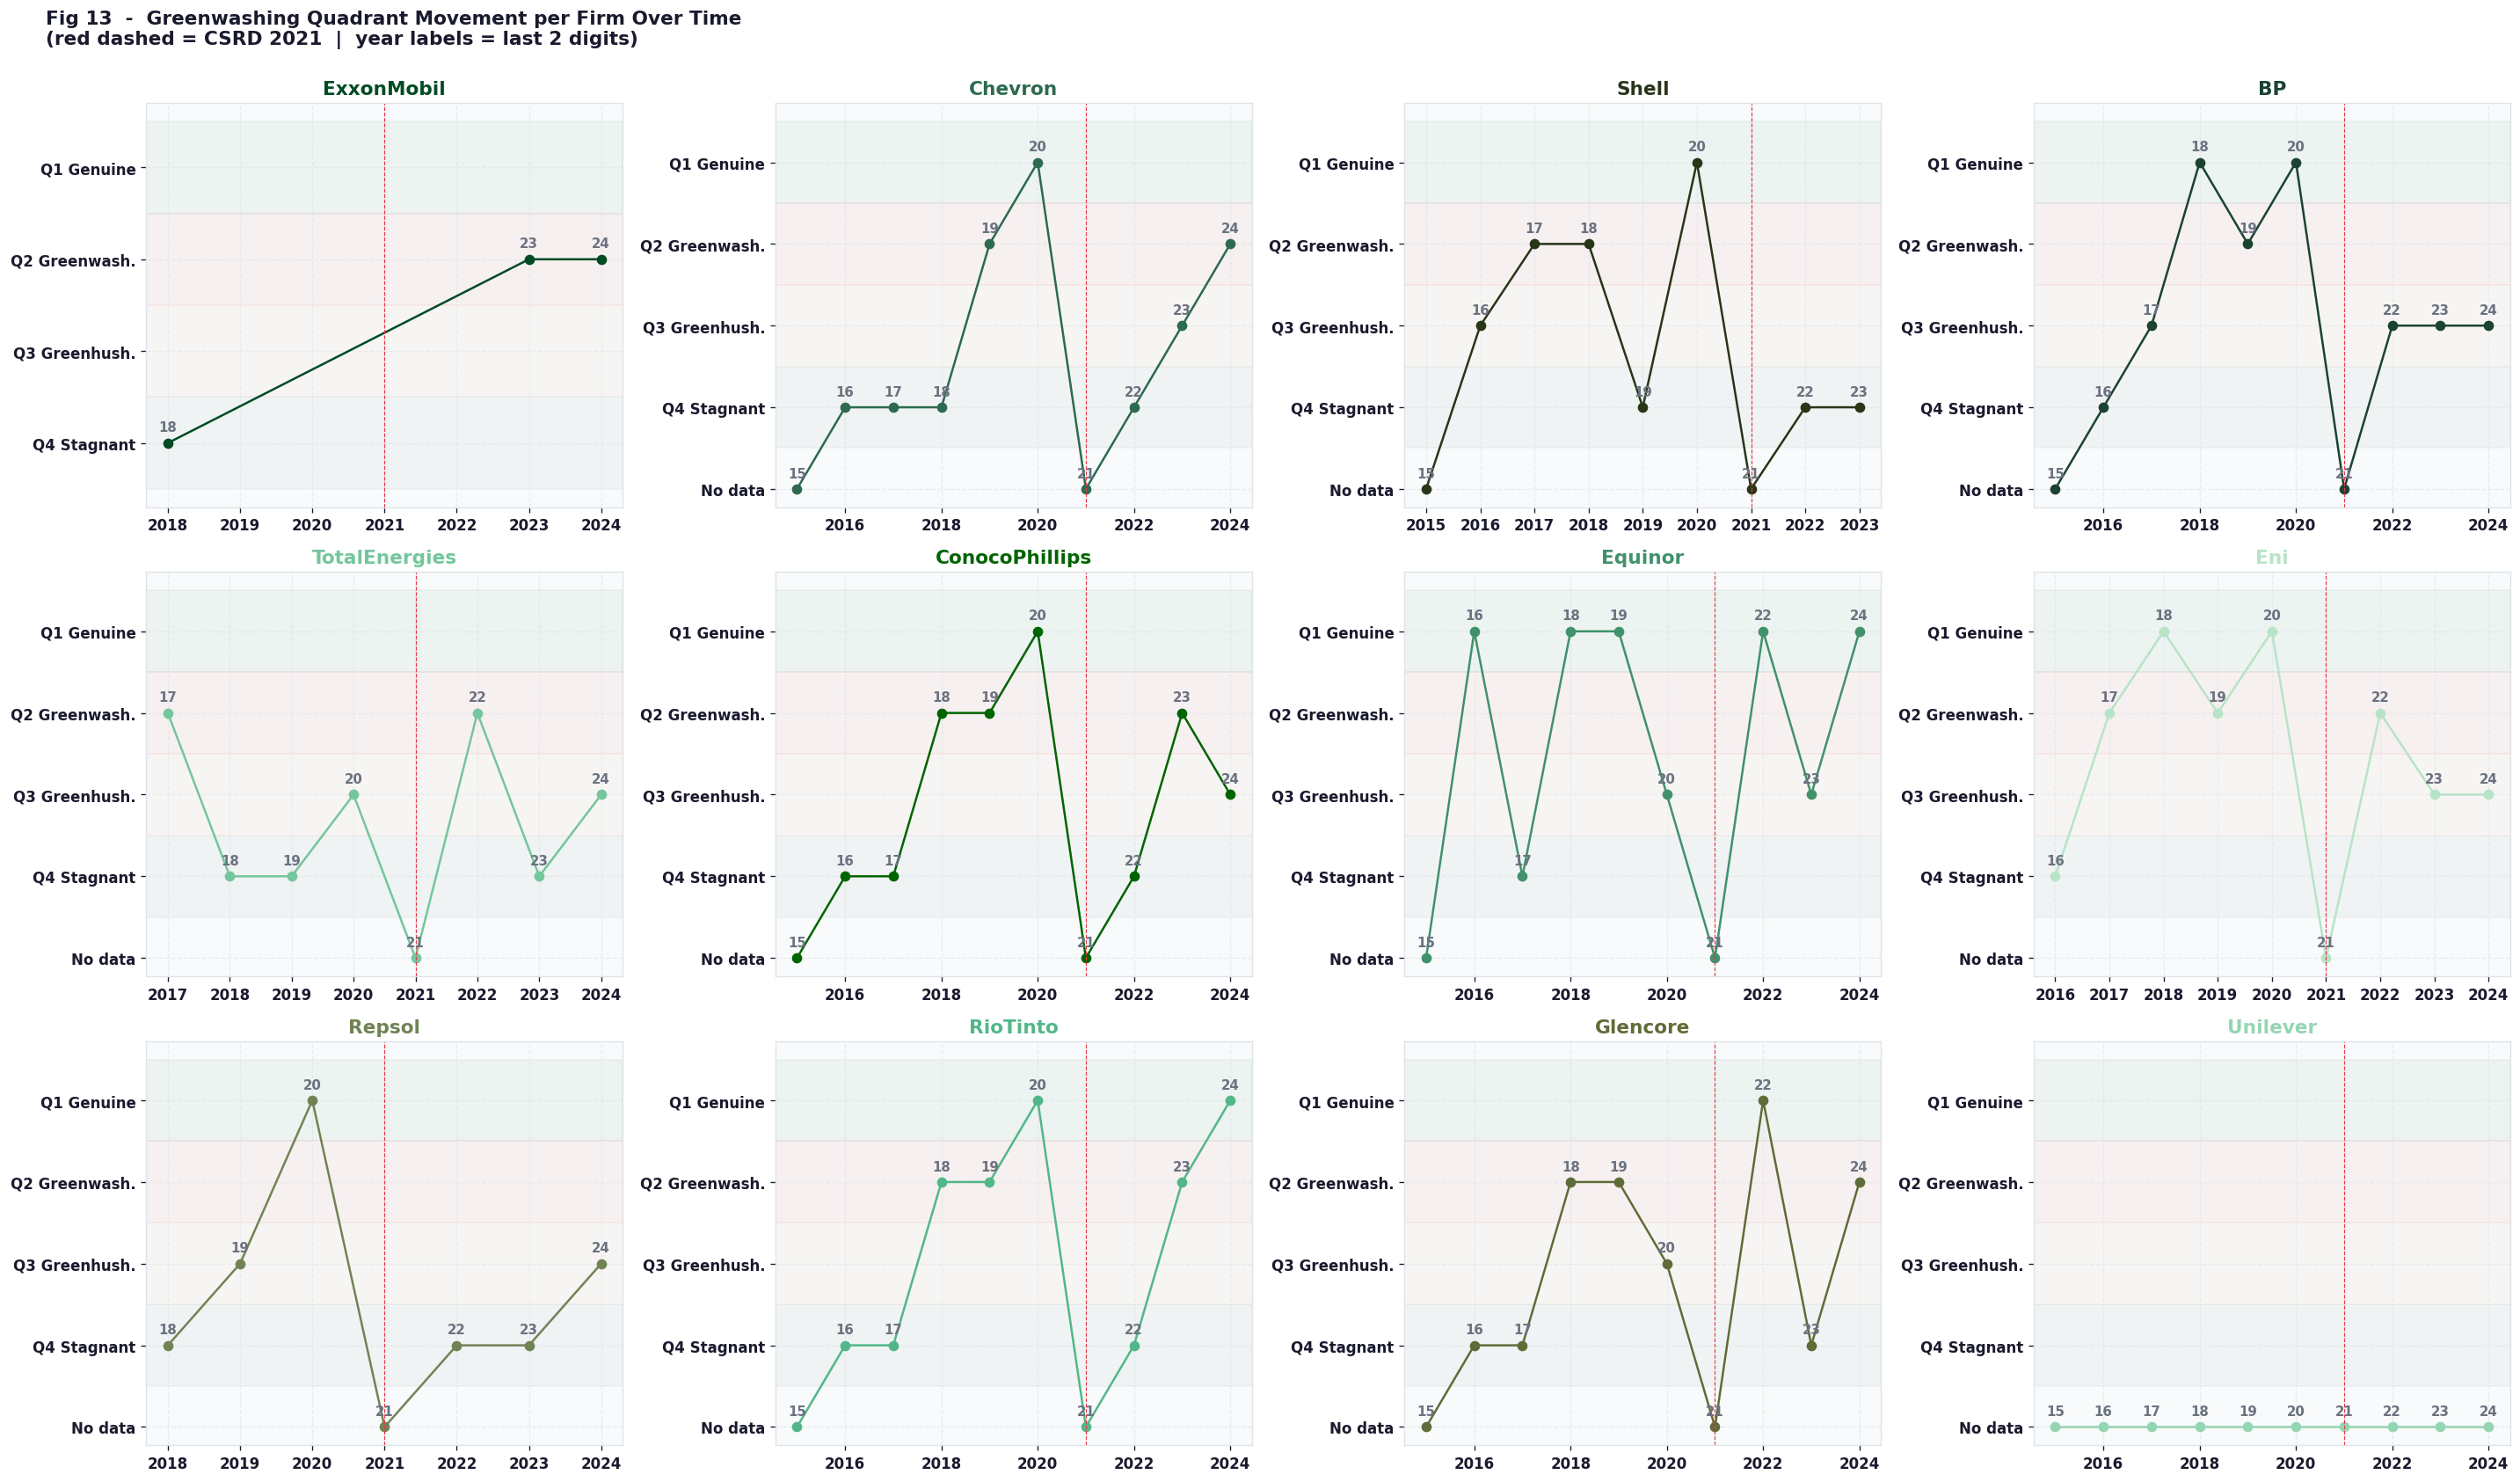

In [15]:
# Figure 13: Greenwashing quadrant movement per firm.
fig13_data = veris_master[["firm_name", "year_to", "greenwashing_quadrant"]].copy()
save_fig_data(fig13_data, "fig13_data.csv")

quadrant_order = ["Q1 Genuine", "Q2 Greenwashing", "Q3 Greenhushing", "Q4 Stagnant", "No data"]
def to_ordinal(q):
    if "1 -" in q: return 4
    if "2 -" in q: return 3
    if "3 -" in q: return 2
    if "4 -" in q: return 1
    return 0
fig13_data["ordinal"] = fig13_data["greenwashing_quadrant"].astype(str).apply(to_ordinal)

fig, axes = plt.subplots(3, 4, figsize=(24, 14))
for ax, firm in zip(axes.ravel(), INDUSTRY_FIRM_ORDER):
    sub = fig13_data[fig13_data["firm_name"] == firm].sort_values("year_to")
    color = GREEN_FIRM_COLORS.get(firm, MUTED)
    ax.plot(sub["year_to"], sub["ordinal"], marker="o", color=color, linewidth=1.5)
    for _, r in sub.iterrows():
        ax.annotate(str(int(r["year_to"]))[-2:], (r["year_to"], r["ordinal"]),
                    xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9, fontweight="bold", color=MUTED)
    ax.set_yticks([0, 1, 2, 3, 4])
    ax.set_yticklabels(["No data", "Q4 Stagnant", "Q3 Greenhush.", "Q2 Greenwash.", "Q1 Genuine"], fontsize=10, fontweight="bold")
    ax.axvline(cfg.CSRD_YEAR, color=WARN, linestyle="--", linewidth=0.7)
    ax.set_title(firm, fontweight="bold", color=color, fontsize=13)
    ax.axhspan(3.5, 4.5, color=PRIMARY, alpha=0.05)
    ax.axhspan(2.5, 3.5, color=WARN,    alpha=0.05)
    ax.axhspan(1.5, 2.5, color=AMBER,   alpha=0.05)
    ax.axhspan(0.5, 1.5, color=MUTED,   alpha=0.05)
fig.suptitle("Fig 13  -  Greenwashing Quadrant Movement per Firm Over Time\n(red dashed = CSRD 2021  |  year labels = last 2 digits)", fontsize=13, fontweight="bold", x=0.02, ha="left", y=1.00)
plt.tight_layout()
save_fig(fig, "fig13_quadrant_movement.png")


19:31:16 [INFO] VERIS -- Saved figure data: fig14_data.csv
19:31:17 [INFO] VERIS -- Saved figure: fig14_word_count.png


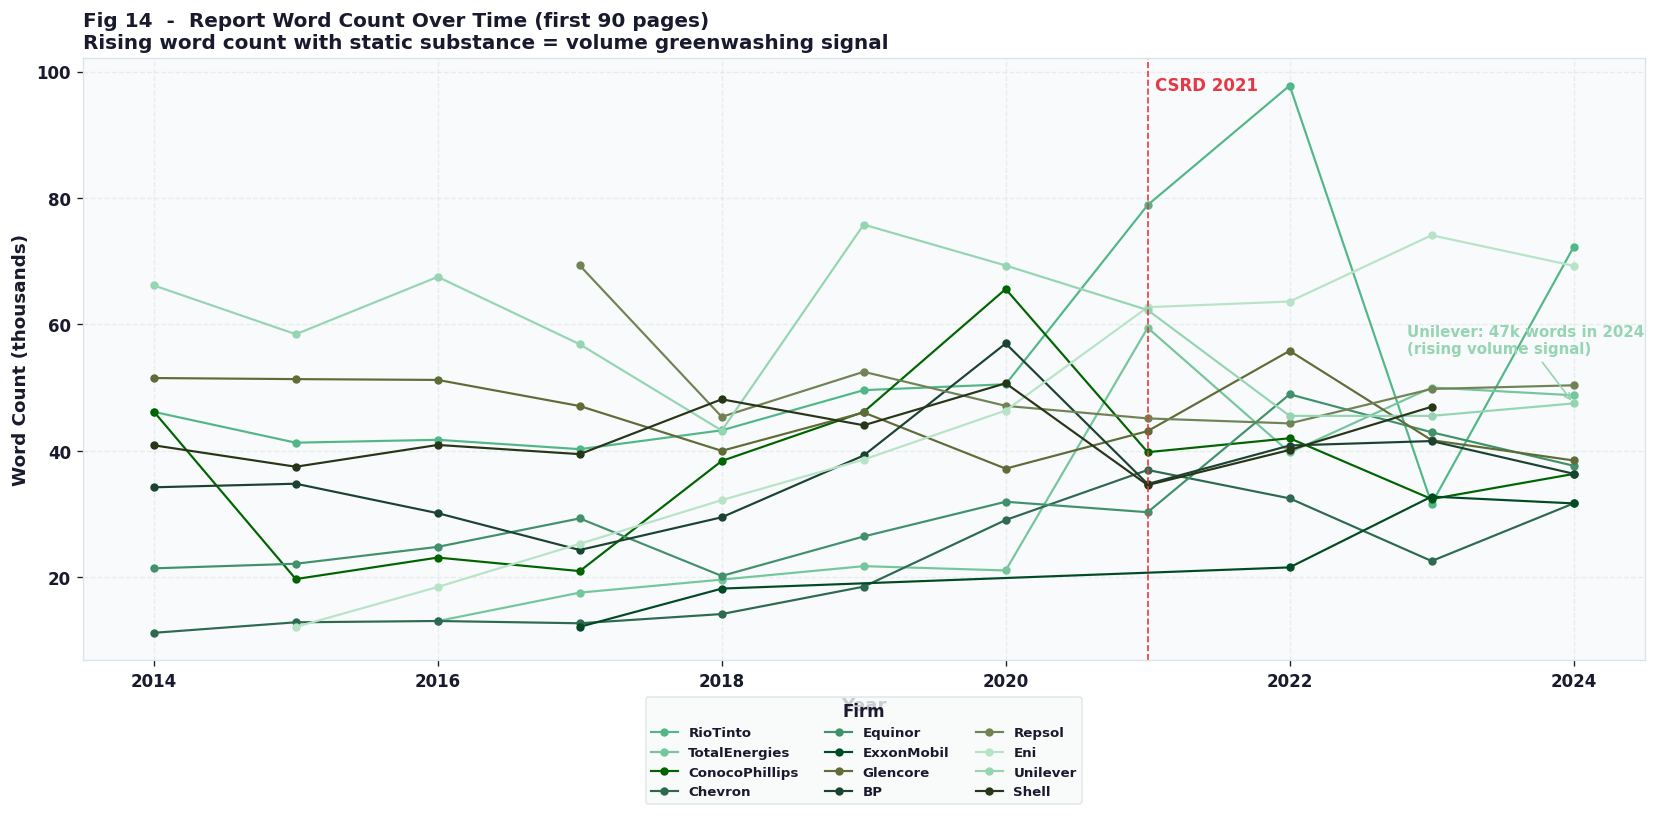

In [16]:
# Figure 14: Report word count over time.
fig14_data = audit[["company", "year", "words"]].copy().rename(columns={"company": "firm_name"})
save_fig_data(fig14_data, "fig14_data.csv")

fig, ax = plt.subplots(figsize=(14, 7))
for firm in cfg.ALL_FIRMS:
    sub = fig14_data[fig14_data["firm_name"] == firm].sort_values("year")
    if sub.empty:
        continue
    ax.plot(sub["year"], sub["words"] / 1000, marker="o", linewidth=1.3, markersize=4,
            color=GREEN_FIRM_COLORS.get(firm, MUTED), label=firm)

ax.axvline(cfg.CSRD_YEAR, color=WARN, linestyle="--", linewidth=1)
ax.text(cfg.CSRD_YEAR + 0.05, ax.get_ylim()[1] * 0.95, "CSRD 2021", color=WARN, fontsize=10, fontweight="bold")

# Unilever 2024 annotation
uni_2024 = fig14_data[(fig14_data["firm_name"] == "Unilever") & (fig14_data["year"] == 2024)]
if not uni_2024.empty:
    uni_words = uni_2024["words"].iloc[0] / 1000
    _uni_col = GREEN_FIRM_COLORS.get("Unilever", MUTED)
    ax.annotate(f"Unilever: {uni_words:.0f}k words in 2024\n(rising volume signal)",
                (2024, uni_words), xytext=(-100, 30), textcoords="offset points",
                fontsize=9, color=_uni_col, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=_uni_col))

ax.set_xlabel("Year")
ax.set_ylabel("Word Count (thousands)")
ax.set_title("Fig 14  -  Report Word Count Over Time (first 90 pages)\nRising word count with static substance = volume greenwashing signal",
             loc="left", fontsize=12, fontweight="bold")
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.25), fontsize=8, title="Firm")
plt.tight_layout()
save_fig(fig, "fig14_word_count.png")


19:31:17 [INFO] VERIS -- Saved figure data: fig15_data.csv
19:31:17 [INFO] VERIS -- Saved figure: fig15_jaccard_heatmap.png


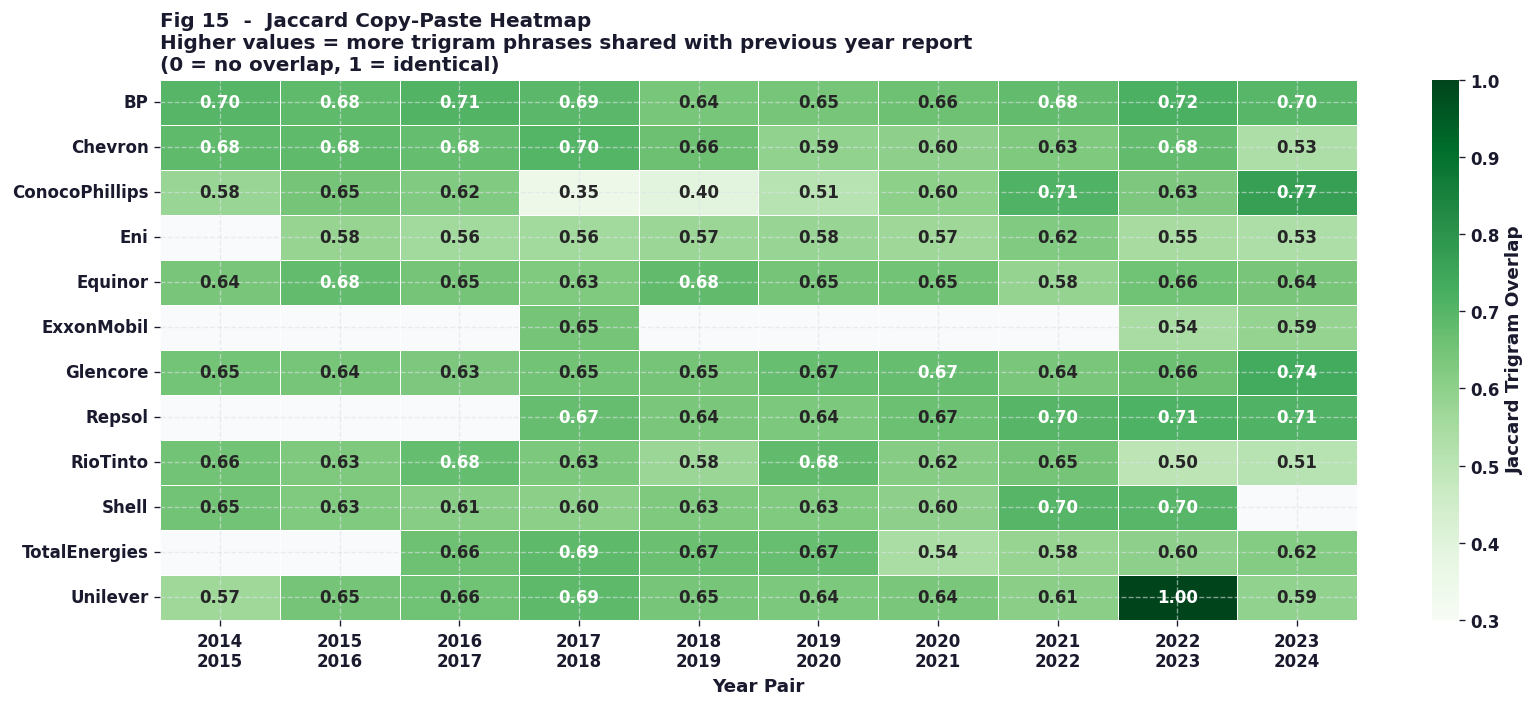

In [17]:
# Figure 15: Jaccard copy-paste heatmap.
fig15_data = drift.pivot_table(index="firm_name", columns="year_from", values="jaccard_overlap", aggfunc="first")
fig15_data.reset_index().to_csv(cfg.CSV_DIR / "fig15_data.csv", index=False)
log.info("Saved figure data: fig15_data.csv")

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(fig15_data, annot=True, fmt=".2f", cmap="Greens", cbar_kws={"label": "Jaccard Trigram Overlap"}, linewidths=0.5, linecolor="white", vmin=0.3, vmax=1.0, ax=ax)
ax.set_xlabel("Year Pair")
ax.set_xticklabels([f"{int(y)}\n{int(y)+1}" for y in fig15_data.columns], rotation=0)
ax.set_ylabel("")
ax.set_title("Fig 15  -  Jaccard Copy-Paste Heatmap\nHigher values = more trigram phrases shared with previous year report\n(0 = no overlap, 1 = identical)", loc="left", fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig15_jaccard_heatmap.png")

19:31:17 [INFO] VERIS -- Saved figure data: fig16_data.csv
19:31:18 [INFO] VERIS -- Saved figure: fig16_correlation_matrix.png


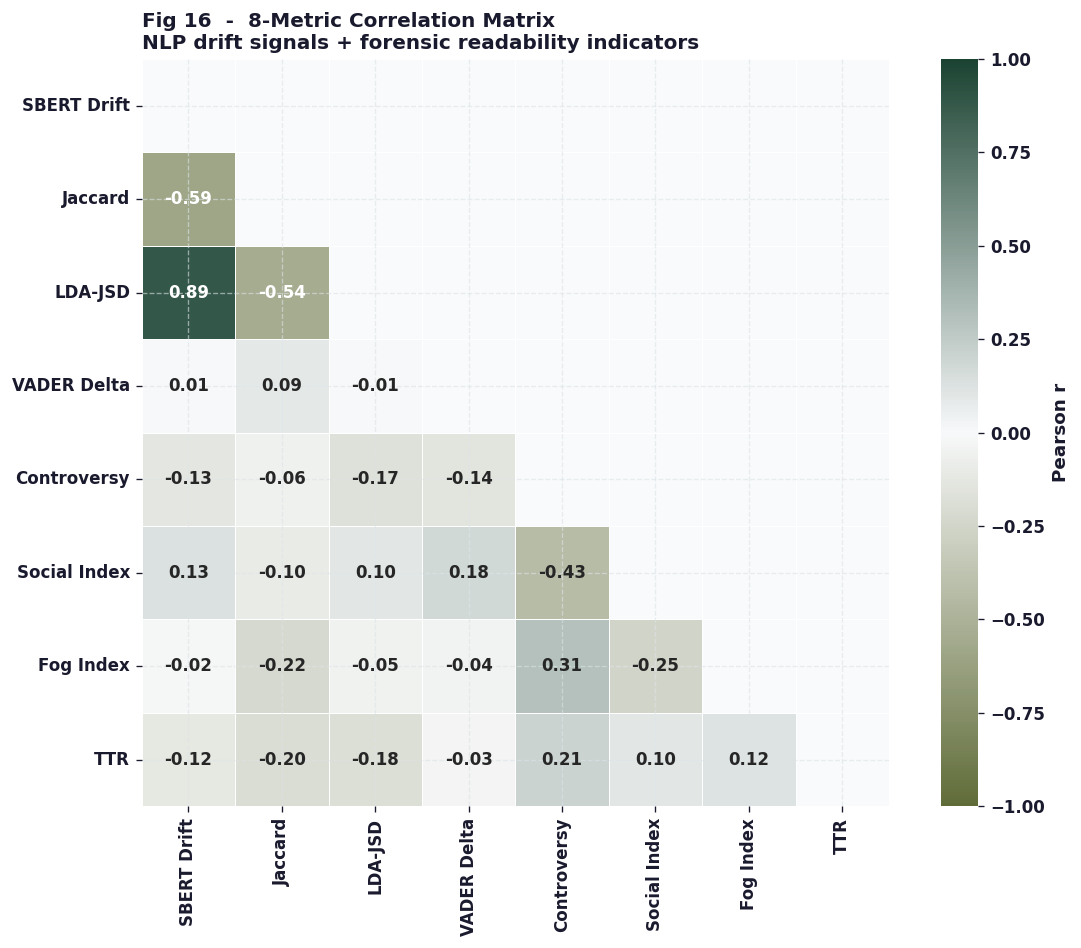

In [18]:
# Figure 16: 8-metric correlation matrix.
corr_cols_display = ["SBERT Drift", "Jaccard", "LDA-JSD", "VADER Delta",
                     "Controversy", "Social Index", "Fog Index", "TTR"]
corr_cols_src = ["sbert_drift", "jaccard_overlap", "lda_jsd", "vader_delta",
                 "controversy_density", "social_index", "gunning_fog_index", "type_token_ratio"]
corr_src = panel[corr_cols_src].corr()
corr_src.columns = corr_cols_display; corr_src.index = corr_cols_display

fig16_data = corr_src.reset_index().rename(columns={"index": "metric"})
save_fig_data(fig16_data, "fig16_data.csv")

mask = np.triu(np.ones_like(corr_src, dtype=bool), k=0)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_src, mask=mask, annot=True, fmt=".2f",
            cmap=green_corr_cmap,   # olive-white-forest green diverging
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "Pearson r"},
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Fig 16  -  8-Metric Correlation Matrix\nNLP drift signals + forensic readability indicators", loc="left", fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig16_correlation_matrix.png")


In [19]:
# LDA Topic Label Table (Table 2b in report).
# Reads lda_topic_labels.csv produced by the LDA celled 03_semantic_drift.ipynb.
# Displays corpus-wide topic summary and saves fig for appendix.

from pathlib import Path
_lda_labels_path = cfg.CSV_DIR / "lda_topic_labels.csv"

if _lda_labels_path.exists():
    topic_tbl = pd.read_csv(_lda_labels_path)
    log.info(f"LDA topic labels loaded: {len(topic_tbl)} topics")

    # Truncate top_words for display (first 8 words only)
    topic_tbl["keywords_short"] = topic_tbl["top_words"].apply(
        lambda s: ", ".join(str(s).split(", ")[:8]) + " ..."
    )

    # Pretty print
    print("\n=== Table 2b: LDA Corpus-Level Topic Summary (k=7) ===")
    print(f"Justification: k=7 aligned with GRI Universal Standards thematic areas.")
    print()
    for _, row in topic_tbl.iterrows():
        print(f"  Topic {int(row['topic_id'])}: {row['label']}")
        print(f"    Keywords: {row['keywords_short']}")
    print()

    # Save a clean CSV for the report appendix
    display_tbl = topic_tbl[["topic_id", "label", "keywords_short"]].rename(
        columns={"topic_id": "Topic", "label": "Label", "keywords_short": "Top Keywords"})
    display_tbl.to_csv(cfg.CSV_DIR / "table2b_lda_topics.csv", index=False)
    log.info("Table 2b saved: table2b_lda_topics.csv")
    display(display_tbl)
else:
    log.warning(f"lda_topic_labels.csv not found at {_lda_labels_path}. "
                "Run 03_semantic_drift.ipynb first.")


19:31:18 [INFO] VERIS -- LDA topic labels loaded: 7 topics
19:31:18 [INFO] VERIS -- Table 2b saved: table2b_lda_topics.csv



=== Table 2b: LDA Corpus-Level Topic Summary (k=7) ===
Justification: k=7 aligned with GRI Universal Standards thematic areas.

  Topic 0: Climate & Net-Zero Commitments
    Keywords: performance, energy, business, safety, management, emissions, oil, gas ...
  Topic 1: Governance, Risk & Compliance
    Keywords: business, emissions, carbon, energy, water, management, performance, environmental ...
  Topic 2: Workforce & Social Pillar
    Keywords: energy, development, gas, net, emissions, management, business, oil ...
  Topic 3: Supply Chain & Scope 3 Emissions
    Keywords: emissions, approach, infrastructure, angola, climate, net, zero, people ...
  Topic 4: Environmental Stewardship (Water / Biodiversity)
    Keywords: gas, emissions, energy, risk, business, carbon, rights, operations ...
  Topic 5: Capital Allocation & Energy Transition
    Keywords: emissions, gas, carbon, energy, climate, business, oil, performance ...
  Topic 6: Community Relations & Human Rights
    Keywords: 

,Topic,Label,Top Keywords
0,0,Climate & Net-Zero Commitments,"performance, energy, business, safety, managem..."
1,1,"Governance, Risk & Compliance","business, emissions, carbon, energy, water, ma..."
2,2,Workforce & Social Pillar,"energy, development, gas, net, emissions, mana..."
3,3,Supply Chain & Scope 3 Emissions,"emissions, approach, infrastructure, angola, c..."
4,4,Environmental Stewardship (Water / Biodiversity),"gas, emissions, energy, risk, business, carbon..."
5,5,Capital Allocation & Energy Transition,"emissions, gas, carbon, energy, climate, busin..."
6,6,Community Relations & Human Rights,"safety, gas, local, oil, business, energy, emi..."


In [20]:
# Greenwashing leaderboard -- year-pairs ranked by VERIS score within valid quadrants only.
#
# Methodological rule (V15.1): rows labelled "Insufficient data" or
# "Insufficient data -- CT coverage discontinuity" are EXCLUDED from ranking because they
# represent structural data limitations, not real greenwashing signal:
#   (a) Insufficient data: firm's first observed year has no prior, so emissions_delta_pct
#       is NaN by construction.
#   (b) CT coverage discontinuity: 2020->2021 year-pairs span the Climate TRACE v5.4.1 basis
#       change (country-share proxy pre-2021 -> facility-direct 2021+), producing spurious
#       50-99% apparent emissions drops that are measurement artefacts, not behaviour.
#
# Primary sort: veris_score descending (language-reality divergence magnitude).
# Secondary sort: |emissions_delta_pct| descending (for ties in VERIS score only).

panel_lb = panel[
    ~panel["greenwashing_quadrant"].str.startswith("Insufficient data", na=False)
].copy()
panel_lb["abs_emissions_delta"] = panel_lb["emissions_delta_pct"].abs().fillna(0)
panel_lb["gap_score"] = panel_lb["veris_score"] + panel_lb["abs_emissions_delta"]
panel_lb = panel_lb.sort_values(
    by=["veris_score", "abs_emissions_delta"],
    ascending=[False, False],
).reset_index(drop=True)
panel_lb.insert(0, "Rank", range(1, len(panel_lb) + 1))
panel_lb["year_label"] = panel_lb.apply(lambda r: f"{int(r['year_from'])}-{int(r['year_to'])}", axis=1)

cols = ["Rank", "firm_name", "year_from", "year_to", "veris_score", "veris_band",
        "sbert_drift", "gunning_fog_index", "type_token_ratio", "emissions_delta_pct",
        "greenwashing_quadrant", "gap_score", "year_label"]
leaderboard = panel_lb[cols].copy()
for c in ["veris_score", "sbert_drift", "gunning_fog_index", "type_token_ratio",
          "emissions_delta_pct", "gap_score"]:
    leaderboard[c] = leaderboard[c].round(4)

leaderboard.to_csv(cfg.LEADERBOARD_CSV, index=False)
leaderboard.to_csv(cfg.VERIS_LEADERBOARD_CSV, index=False)
log.info(
    f"Leaderboard saved: {cfg.LEADERBOARD_CSV.name} and {cfg.VERIS_LEADERBOARD_CSV.name} "
    f"({len(leaderboard)} classifiable year-pairs; excluded {len(panel) - len(leaderboard)} 'Insufficient data' rows)"
)
log.info("Top 5 greenwashing events (clean):")
for _, r in leaderboard.head(5).iterrows():
    log.info(f"  #{int(r['Rank'])} {r['firm_name']:<15} {r['year_label']}  VERIS={r['veris_score']:.3f}  {r['greenwashing_quadrant']}")
display(leaderboard.head(15))


19:31:18 [INFO] VERIS -- Leaderboard saved: leaderboard.csv and veris_leaderboard.csv (79 classifiable year-pairs; excluded 27 'Insufficient data' rows)
19:31:18 [INFO] VERIS -- Top 5 greenwashing events (clean):
19:31:18 [INFO] VERIS --   #1 ExxonMobil      2022-2023  VERIS=0.894  2 - Greenwashing signal
19:31:18 [INFO] VERIS --   #2 RioTinto        2023-2024  VERIS=0.893  1 - Genuine improvement
19:31:18 [INFO] VERIS --   #3 RioTinto        2018-2019  VERIS=0.843  2 - Greenwashing signal
19:31:18 [INFO] VERIS --   #4 RioTinto        2022-2023  VERIS=0.702  2 - Greenwashing signal
19:31:18 [INFO] VERIS --   #5 Chevron         2023-2024  VERIS=0.668  2 - Greenwashing signal


,Rank,firm_name,year_from,year_to,veris_score,veris_band,sbert_drift,gunning_fog_index,type_token_ratio,emissions_delta_pct,greenwashing_quadrant,gap_score,year_label
0,1,ExxonMobil,2022,2023,0.8944,Very High,0.1696,21.2041,0.1277,0.0033,2 - Greenwashing signal,0.8977,2022-2023
1,2,RioTinto,2023,2024,0.8935,Very High,0.1623,16.5029,0.1301,-0.0170,1 - Genuine improvement,0.9105,2023-2024
2,3,RioTinto,2018,2019,0.8434,Very High,0.1557,17.1901,0.1124,0.0155,2 - Greenwashing signal,0.8589,2018-2019
3,4,RioTinto,2022,2023,0.7018,Very High,0.1313,19.9598,0.1488,0.0117,2 - Greenwashing signal,0.7135,2022-2023
4,5,Chevron,2023,2024,0.6685,Very High,0.1160,18.2897,0.1286,0.0009,2 - Greenwashing signal,0.6694,2023-2024
5,6,ConocoPhillips,2017,2018,0.6644,Very High,0.1284,17.1298,0.1363,0.0263,2 - Greenwashing signal,0.6907,2017-2018
6,7,ConocoPhillips,2018,2019,0.3427,Very High,0.0646,18.9818,0.1863,0.0048,2 - Greenwashing signal,0.3475,2018-2019
7,8,Equinor,2017,2018,0.3185,Very High,0.0527,18.9041,0.1432,-0.0154,1 - Genuine improvement,0.3339,2017-2018
8,9,Equinor,2021,2022,0.3095,Very High,0.0441,19.7082,0.1334,-0.0476,1 - Genuine improvement,0.3571,2021-2022
9,10,ConocoPhillips,2022,2023,0.2659,Very High,0.0347,19.7336,0.1309,0.0718,2 - Greenwashing signal,0.3377,2022-2023
